# Deterministic periodic antibiotic environments

This notebook examines how deterministic temporal structure in antibiotic exposure changes plasmid maintenance and population survival. Antibiotic concentration is specified as a daily control vector, with finite-period waveforms and constant on/off controls. The analyses first evaluate single-strain dynamics, including sinusoidal and triangular waveforms, and then extend the same environments to complete communities.


In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math


In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    # Tick labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Axis labels
    "axes.labelsize": 16,

    # Plot titles
    "axes.titlesize": 16,
    "figure.titlesize": 16,

    # Legends
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,

    # General text
    "font.size": 14,

    # Optional: make saved figures cleaner
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

plt.rcParams.update({
    "axes.linewidth": 1.2,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "legend.frameon": False,
})

## Repository paths and simulation parameters

The notebook writes simulations and figures into directories labeled by antibiotic amplitude and experiment duration. This allows independent simulation batches to be compared without overwriting previous results.


In [ ]:
num_days = 64
Amin = 0.0
Amax = 512.0

extinction_threshold = 1e5
B_initial = 1e6

M_fixed = 5
num_communities_M10 = 1000

A_values = [0] + [2**i for i in range(-2, 11)]
print("A=",A_values)

num_random_communities_per_size = 1000

tau_values = [64, 32, 16, 8, 4, 2]
print("tau=",tau_values)

max_total_simulations = 1000


A= [0, 0.25, 0.5, 1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
tau= [64, 32, 16, 8, 4, 2]


In [ ]:
PROJECT_ROOT = Path.cwd()

codePath = PROJECT_ROOT / 'code'
dataPath = PROJECT_ROOT / 'data'
envPath = PROJECT_ROOT / 'env'
runPath = PROJECT_ROOT / f"runs/A{Amax:g}_T{num_days:g}"
figPath = PROJECT_ROOT / f"figures/A{Amax:g}_T{num_days:g}"

for p in [runPath, figPath]:
    p.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('codePath     =', codePath)
print('dataPath     =', dataPath)
print('runPath      =', runPath)
print('figPath      =', figPath)


Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT
codePath     = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/code
dataPath     = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/data
runPath      = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T64
figPath      = /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64


In [ ]:
REPO = False

if REPO:
    repo_url = 'https://github.com/ccg-esb-lab/plasmidNoise.git'
    repo_name = 'plasmidNoise'

    if not Path(repo_name).exists():
        !git clone {repo_url}

    PROJECT_ROOT = Path(repo_name).resolve()
    codePath = PROJECT_ROOT / 'code'
    dataPath = PROJECT_ROOT / 'data'
    envPath = PROJECT_ROOT / 'env'
    runPath = PROJECT_ROOT / f"runs/A{Amax:g}_T{num_days:g}"
    figPath = PROJECT_ROOT / f"figures/A{Amax:g}_T{num_days:g}"

    for p in [runPath, figPath]:
        p.mkdir(parents=True, exist_ok=True)

if str(codePath) not in sys.path:
    sys.path.insert(0, str(codePath))

print('Files in codePath:')
for p in sorted(codePath.glob('*.py')):
    print('  ', p.name)


Files in codePath:
   plasmidNoise_model.py
   plasmidNoise_plotter.py


## Model modules

The same parameterized plasmid population model is used as in the constant-environment notebook. Periodic environments are introduced only through the daily antibiotic control vector.


In [ ]:
import plasmidNoise_model as pn
import plasmidNoise_plotter as pp


## Parameterized strain set

The strain library defines host-specific growth, susceptibility, plasmid cost, segregational loss, and conjugation permissiveness. These parameters determine which strains maintain the plasmid during selection-free intervals and which strains collapse when antibiotic exposure returns.


In [ ]:
params_csv = dataPath / 'pOXA48_model_params.csv'
model_params = pn.load_parameter_table(params_csv)

print(model_params.shape)
model_params.head()


(50, 20)


,strain,display_name,species,color,r_p,affinity_p,k_star_p,r_0,affinity_0,k_star_0,lambda_loss,gamma,Km_p,Vmax_p,alpha_p,k_p,Km_0,Vmax_0,alpha_0,k_0
0,C001,PF_EC01,E,#d60000,984410100.0,4.900000e-10,0.000488,877563800.0,5.280000e-10,0.000244,0.02,0.0,1.0,4.900000e-10,1.000000e-12,0.015625,1.0,5.280000e-10,1.000000e-10,0.03125
1,C002,PF_EC02,E,#018700,550386500.0,7.600000e-10,0.062500,678608700.0,6.650000e-10,0.000244,0.02,0.0,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.650000e-10,1.000000e-10,0.03125
2,C006,PF_EC03,E,#b500ff,890018480.0,7.600000e-10,0.062500,815145500.0,6.540000e-10,0.000122,0.02,0.0,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.540000e-10,1.000000e-10,0.06250
3,C011,PF_EC04,E,#05acc6,776372125.0,8.370000e-10,0.000488,770241720.0,6.580000e-10,0.000244,0.02,0.0,1.0,8.370000e-10,1.000000e-12,0.015625,1.0,6.580000e-10,1.000000e-10,0.03125
4,C012,PF_EC05,E,#97ff00,772746800.0,6.300000e-10,0.062500,641598800.0,7.830000e-10,0.000122,0.02,0.0,1.0,6.300000e-10,1.000000e-12,0.000122,1.0,7.830000e-10,1.000000e-10,0.06250


In [ ]:
selected_strains = [
    'K213',
    'K225',
    'K038',
    'K177',
    'C201',
    'C324',
    'K216',
    'K112',
    'K037',
    'K253',
    'K209',
    'K248',
    'C063',
    'C107',
    'C286',
    'C002',
    'C006',
    'C022',
    'C247',
    'C290'
]

model_params_filtered = model_params[
    model_params["strain"].isin(selected_strains)
].copy()

strain_list = sorted(model_params_filtered["strain"].unique())

print("Number of selected strains:", len(strain_list))
print(strain_list)

display(model_params_filtered)
#model_params=model_params_filtered.copy()


Number of selected strains: 20
['C002', 'C006', 'C022', 'C063', 'C107', 'C201', 'C247', 'C286', 'C290', 'C324', 'K037', 'K038', 'K112', 'K177', 'K209', 'K213', 'K216', 'K225', 'K248', 'K253']


,strain,display_name,species,color,r_p,affinity_p,k_star_p,r_0,affinity_0,k_star_0,lambda_loss,gamma,Km_p,Vmax_p,alpha_p,k_p,Km_0,Vmax_0,alpha_0,k_0
1,C002,PF_EC02,E,#018700,5.503865e+08,7.600000e-10,0.062500,6.786087e+08,6.650000e-10,0.000244,0.02,0.000000e+00,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.650000e-10,1.000000e-10,0.031250
2,C006,PF_EC03,E,#b500ff,8.900185e+08,7.600000e-10,0.062500,8.151455e+08,6.540000e-10,0.000122,0.02,0.000000e+00,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.540000e-10,1.000000e-10,0.062500
6,C022,PF_EC07,E,#ff8ec8,1.039553e+09,3.790000e-10,0.062500,1.013229e+09,4.150000e-10,0.000488,0.02,0.000000e+00,1.0,3.790000e-10,1.000000e-12,0.000122,1.0,4.150000e-10,1.000000e-10,0.015625
9,C063,PF_EC10,E,#afa5ff,1.071282e+09,5.660000e-10,0.031250,8.472142e+08,7.370000e-10,0.000488,0.02,8.628693e-13,1.0,5.660000e-10,1.000000e-12,0.000244,1.0,7.370000e-10,1.000000e-10,0.015625
11,C107,PF_EC12,E,#9a6900,9.093514e+08,5.190000e-10,0.062500,9.767934e+08,4.810000e-10,0.000488,0.02,7.479731e-12,1.0,5.190000e-10,1.000000e-12,0.000122,1.0,4.810000e-10,1.000000e-10,0.015625
15,C201,PF_EC16,E,#c86e66,1.121715e+09,4.910000e-10,0.062500,1.040166e+09,5.550000e-10,0.000244,0.02,6.852673e-11,1.0,4.910000e-10,1.000000e-12,0.000122,1.0,5.550000e-10,1.000000e-10,0.031250
18,C247,PF_EC19,E,#a877ac,9.811784e+08,6.080000e-10,0.062500,9.423508e+08,6.200000e-10,0.000122,0.02,0.000000e+00,1.0,6.080000e-10,1.000000e-12,0.000122,1.0,6.200000e-10,1.000000e-10,0.062500
20,C286,PF_EC21,E,#f4bfb1,1.020861e+09,5.550000e-10,0.062500,8.386482e+08,4.900000e-10,0.000488,0.02,2.790403e-12,1.0,5.550000e-10,1.000000e-12,0.000122,1.0,4.900000e-10,1.000000e-10,0.015625
21,C290,PF_EC22,E,#ff28fd,9.735538e+08,6.150000e-10,0.062500,9.885546e+08,6.620000e-10,0.000122,0.02,0.000000e+00,1.0,6.150000e-10,1.000000e-12,0.000122,1.0,6.620000e-10,1.000000e-10,0.062500
24,C324,PF_EC25,E,#ff6200,9.236833e+08,6.780000e-10,0.003906,1.003584e+09,5.470000e-10,0.000977,0.02,8.950370e-12,1.0,6.780000e-10,1.000000e-12,0.001953,1.0,5.470000e-10,1.000000e-10,0.007812


In [ ]:
def find_absorbing_extinction_time(
    time,
    density,
    *,
    extinction_threshold=extinction_threshold,
):
    """
    Determine whether a density time-series went extinct.

    Extinction is defined as the first time point after which density remains
    <= extinction_threshold until the end of the time-series.

    Parameters
    ----------
    time : array-like
        Time points, for example day or transfer.

    density : array-like
        Density values.

    extinction_threshold : float
        Density threshold below which the population is considered extinct.

    Returns
    -------
    dict
        Extinction summary.
    """

    time = np.asarray(time)
    density = np.asarray(density, dtype=float)

    if len(time) != len(density):
        raise ValueError("time and density must have the same length.")

    if len(density) == 0:
        return {
            "went_extinct": np.nan,
            "extinction_time": np.nan,
            "extinction_index": np.nan,
            "final_density": np.nan,
            "max_density": np.nan,
            "min_density": np.nan,
        }

    extinct_mask = density <= extinction_threshold

    went_extinct = False
    extinction_index = np.nan
    extinction_time = np.nan

    # Absorbing extinction:
    # find first index i such that all densities from i onward are below threshold.
    for i in range(len(density)):
        if np.all(extinct_mask[i:]):
            went_extinct = True
            extinction_index = i
            extinction_time = time[i]
            break

    return {
        "went_extinct": went_extinct,
        "extinction_time": extinction_time,
        "extinction_index": extinction_index,
        "final_density": density[-1],
        "max_density": np.nanmax(density),
        "min_density": np.nanmin(density),
    }

def analyze_simulation_extinction(
    result_or_df,
    *,
    density_extinction_threshold=extinction_threshold,
):
    """
    Analyze extinction from a simulation result or from a daily dynamics dataframe.

    This returns extinction status for:
    - total strain density: Bp + Bempty
    - plasmid-bearing subpopulation: Bp
    - plasmid-free subpopulation: Bempty

    Parameters
    ----------
    result_or_df : SimulationResult or pandas.DataFrame
        A loaded simulation result, or the output of
        extract_daily_strain_subpopulation_frequencies().

    density_extinction_threshold : float
        Density threshold below which a population is considered extinct.

    Returns
    -------
    extinction_df : pandas.DataFrame
        One row per strain and population type.
    """

    if isinstance(result_or_df, pd.DataFrame):
        daily_df = result_or_df.copy()
        run_id = daily_df["run_id"].iloc[0] if "run_id" in daily_df.columns and len(daily_df) > 0 else None
    else:
        result = result_or_df
        run_id = result.run_id

        daily_df = extract_daily_strain_subpopulation_frequencies(
            result,
            density_extinction_threshold=density_extinction_threshold,
        )

    rows = []

    density_specs = [
        {
            "population": "total",
            "density_col": "Btotal_final",
        },
        {
            "population": "plasmid_bearing",
            "density_col": "Bp_final",
        },
        {
            "population": "plasmid_free",
            "density_col": "Bempty_final",
        },
    ]

    for strain, strain_df in daily_df.groupby("strain"):

        strain_df = strain_df.sort_values("day")

        for spec in density_specs:

            density_col = spec["density_col"]
            population = spec["population"]

            summary = find_absorbing_extinction_time(
                strain_df["day"].to_numpy(),
                strain_df[density_col].to_numpy(),
                extinction_threshold=density_extinction_threshold,
            )

            rows.append(
                {
                    "run_id": run_id,
                    "strain": strain,
                    "population": population,
                    "density_col": density_col,
                    "went_extinct": summary["went_extinct"],
                    "extinction_day": summary["extinction_time"],
                    "extinction_index": summary["extinction_index"],
                    "initial_density": strain_df[density_col].iloc[0],
                    "final_density": summary["final_density"],
                    "max_density": summary["max_density"],
                    "min_density": summary["min_density"],
                    "extinction_threshold": density_extinction_threshold,
                }
            )

    extinction_df = pd.DataFrame(rows)

    return extinction_df


In [ ]:
from matplotlib.lines import Line2D
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def make_strain_color_map(
    strains,
    model_params=None,
    strain_col="strain",
    color_col="color",
):
    """
    Build a strain -> color map.

    Priority:
    1. Use model_params[color_col] if available.
    2. Fall back to matplotlib default colors for missing strains.

    Parameters
    ----------
    strains : list-like
        Strain names to color.

    model_params : pandas.DataFrame, optional
        Parameter table containing strain and color columns.

    strain_col : str
        Column name with strain IDs.

    color_col : str
        Column name with strain colors.

    Returns
    -------
    dict
        strain -> color
    """

    strains = sorted([str(s) for s in strains])

    default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    strain_color_map = {
        strain: default_colors[i % len(default_colors)]
        for i, strain in enumerate(strains)
    }

    if model_params is None:
        return strain_color_map

    if strain_col not in model_params.columns:
        return strain_color_map

    if color_col not in model_params.columns:
        return strain_color_map

    color_df = (
        model_params[[strain_col, color_col]]
        .dropna()
        .copy()
    )

    color_df[strain_col] = color_df[strain_col].astype(str)

    for strain in strains:
        colors = (
            color_df.loc[color_df[strain_col] == strain, color_col]
            .dropna()
            .astype(str)
            .unique()
        )

        if len(colors) > 0:
            strain_color_map[strain] = colors[0]

    return strain_color_map


## Periodic treatment schedules

Periodic environments are generated as daily antibiotic time series between $A_{\min}$ and $A_{\max}$. Finite values of $	au$ define the timescale of antibiotic fluctuation, while the off and on controls represent constant weak and constant strong selection. These schedules test whether plasmid stability depends on the duration and recurrence of selection-free intervals.


In [ ]:
# Experiment 4
# Complete community in periodic environments.

exp4_run_path = runPath / "experiment4_periodic_environments"
exp4_run_path.mkdir(parents=True, exist_ok=True)

exp4_fig_path = figPath / "experiment4_periodic_environments"
exp4_fig_path.mkdir(parents=True, exist_ok=True)

complete_community_members = sorted(model_params["strain"].unique())

print("Complete community size:", len(complete_community_members))
print("First strains:", complete_community_members[:10])


print("Amin:", Amin)
print("Amax:", Amax)
print("tau_values:", tau_values)
print("num_days:", num_days)


Complete community size: 50
First strains: ['C001', 'C002', 'C006', 'C011', 'C012', 'C021', 'C022', 'C031', 'C051', 'C063']
Amin: 0.0
Amax: 512.0
tau_values: [64, 32, 16, 8, 4, 2]
num_days: 64


In [ ]:
def format_tau_label(tau):
    if tau == 0:
        return "off"
    elif tau == "on" or tau == np.inf:
        return "on"
    else:
        return fr"$\tau={tau}$"


def format_tau_for_filename(tau):
    if tau == 0:
        return "off"
    elif tau == "on" or tau == np.inf:
        return "on"
    else:
        return f"tau{tau:g}"


def make_periodic_environment(
    n_transfers,
    Amin=0.0,
    Amax=4.0,
    tau=4,
    phase=0.0,
    kind="sine",
):
    """
    Generate a periodic antibiotic environment.

    tau = 0:
        always off, A(t) = Amin

    tau = "on" or np.inf:
        always on, A(t) = Amax

    tau > 0:
        periodic environment that starts off.

    For kind="sine":
        smooth periodic environment.
        With phase=0, starts at Amin.

    For kind="square":
        block periodic environment.
        With phase=0, starts at Amin.

    For kind="triangle":
        linear rise and fall.
        With phase=0, starts at Amin.
    """

    transfer = np.arange(n_transfers)

    # Always on control
    if isinstance(tau, str) and tau.lower() == "on":
        A = np.full(n_transfers, Amax)

    elif tau == np.inf:
        A = np.full(n_transfers, Amax)

    # Always off control
    elif tau == 0:
        A = np.full(n_transfers, Amin)

    # Periodic environments
    else:
        tau_numeric = float(tau)

        if tau_numeric <= 0:
            raise ValueError("For periodic environments, tau must be > 0.")

        if kind == "sine":
            mid = 0.5 * (Amax + Amin)
            amp = 0.5 * (Amax - Amin)

            # Starts at Amin when phase=0.
            A = mid - amp * np.cos(
                2 * np.pi * (transfer - phase) / tau_numeric
            )

        elif kind == "square":
            cycle_position = ((transfer - phase) % tau_numeric) / tau_numeric

            # Starts OFF when phase=0.
            A = np.where(cycle_position < 0.5, Amin, Amax)

        elif kind == "triangle":
            cycle_position = ((transfer - phase) % tau_numeric) / tau_numeric

            # Starts OFF when phase=0.
            triangle = np.where(
                cycle_position < 0.5,
                2.0 * cycle_position,
                2.0 * (1.0 - cycle_position),
            )

            A = Amin + triangle * (Amax - Amin)

        else:
            raise ValueError("kind must be 'sine', 'square', or 'triangle'.")

    A = np.clip(A, Amin, Amax)

    env = pd.DataFrame(
        {
            "transfer": transfer,
            "A": A,
        }
    )

    return env


In [ ]:
def extract_total_daily_subpopulation_densities(
    result,
    *,
    density_extinction_threshold=1.0,
):
    """
    Extract total daily endpoint densities across all members.
    Works for single-strain and multistrain simulations.
    """

    rows = []
    n = len(result.members)

    for transfer_idx, tr in enumerate(result.transfers):
        y = tr["y"]

        Bp = y[2 : 2 + n, -1].copy()
        Bempty = y[2 + n : 2 + 2 * n, -1].copy()

        Bp[Bp < density_extinction_threshold] = 0.0
        Bempty[Bempty < density_extinction_threshold] = 0.0

        Bp_total = Bp.sum()
        Bempty_total = Bempty.sum()
        Btotal = Bp_total + Bempty_total

        rows.append(
            {
                "run_id": result.run_id,
                "transfer": transfer_idx,
                "day": transfer_idx + 1,
                "A_initial": tr.get("A_initial", np.nan),
                "Bp_final": Bp_total,
                "Bempty_final": Bempty_total,
                "Btotal_final": Btotal,
                "plasmid_fraction": Bp_total / Btotal if Btotal > 0 else np.nan,
            }
        )

    return pd.DataFrame(rows)


## Sinusoidal periodic environments

Sinusoidal treatments provide the main deterministic fluctuation regime. Antibiotic exposure starts from low selection and varies smoothly through each period, allowing direct comparison between rapid fluctuations, longer weak-selection intervals, and constant controls.


[64, 32, 16, 8, 4, 2]
Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/periodic_environments_on_to_off_subplots.png


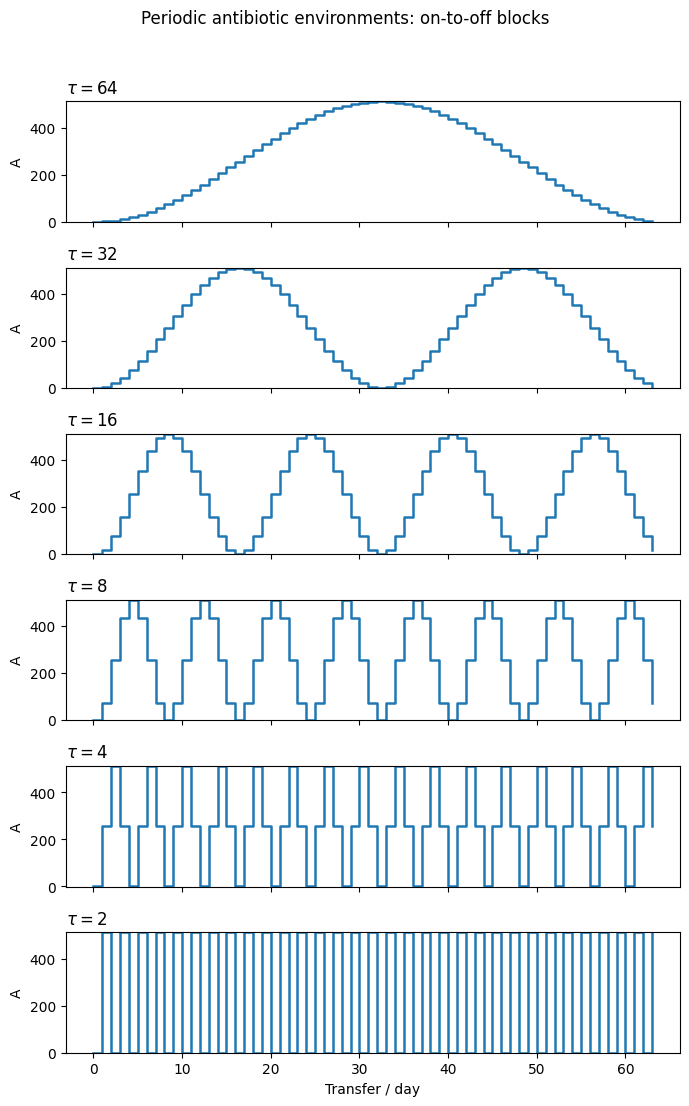

In [ ]:
# Visualize periodic environments before running simulations.
# One subplot row per tau.
#
# tau = 0 means always ON.
# tau > 0 means ON blocks and OFF blocks of length tau.
print(tau_values)
n_rows = len(tau_values)

fig, axes = plt.subplots(
    n_rows, 1,
    figsize=(7.0, 1.8 * n_rows),
    sharex=True,
    sharey=True,
)

if n_rows == 1:
    axes = [axes]

for ax, tau in zip(axes, tau_values):
    env = make_periodic_environment(
        n_transfers=num_days,
        Amin=Amin,
        Amax=Amax,
        tau=tau,
    )

    ax.step(
        env["transfer"],
        env["A"],
        where="post",
        linewidth=1.8,
    )

    ax.set_ylim(Amin - 0.1, Amax + 0.1)
    ax.set_ylabel("A")

    tau_label = "no drug" if tau == 0 else fr"$\tau={tau}$"
    ax.set_title(tau_label, loc="left")

axes[-1].set_xlabel("Transfer / day")
fig.suptitle("Periodic antibiotic environments: on-to-off blocks", y=1.02)

fig.tight_layout()

save_file = exp4_fig_path / "periodic_environments_on_to_off_subplots.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)


In [ ]:
# Simulation config for periodic environments.

experiment4_config = pn.SimulationConfig(
    season_duration=24.0,
    points_per_season=121,
    R0=1.0,
    B0_total=1e6,
    dilution=0.01,
    extinction_threshold=extinction_threshold,
    solver_method="LSODA",
    uptake_mode="monod",
    initial_plasmid_fraction=1.0,
)


In [ ]:
def extract_final_community_state(
    result,
    density_extinction_threshold=extinction_threshold,
):
    """
    Extract final Bp, Bempty, Btotal, and plasmid frequency
    from a loaded simulation result.

    Densities below density_extinction_threshold are treated as extinct.
    """
    tr = result.transfers[-1]
    y = tr["y"]
    n = len(result.members)

    Bp_final_by_strain = y[2 : 2 + n, -1].copy()
    Bempty_final_by_strain = y[2 + n : 2 + 2 * n, -1].copy()

    Bp_final_by_strain[Bp_final_by_strain < density_extinction_threshold] = 0.0
    Bempty_final_by_strain[Bempty_final_by_strain < density_extinction_threshold] = 0.0

    Bp_final = Bp_final_by_strain.sum()
    Bempty_final = Bempty_final_by_strain.sum()
    Btotal_final = Bp_final + Bempty_final

    if Btotal_final > 0:
        plasmid_frequency = Bp_final / Btotal_final
    else:
        plasmid_frequency = np.nan

    return {
        "Bp_final": Bp_final,
        "Bempty_final": Bempty_final,
        "Btotal_final": Btotal_final,
        "plasmid_frequency": plasmid_frequency,
    }
def extract_daily_strain_frequencies(
    result,
    density_extinction_threshold=extinction_threshold,
):
    """
    Extract daily final frequencies of each strain from a simulation.

    For each transfer/day, the final strain density is:

        Btotal_i = Bp_i + Bempty_i

    and the strain frequency is:

        frequency_i = Btotal_i / sum_j Btotal_j

    Densities below density_extinction_threshold are treated as extinct.

    Returns
    -------
    df : pandas.DataFrame
        One row per strain per transfer.
    """

    rows = []

    members = list(result.members)
    n = len(members)

    for transfer_idx, tr in enumerate(result.transfers):
        y = tr["y"]

        Bp_final_by_strain = y[2 : 2 + n, -1].copy()
        Bempty_final_by_strain = y[2 + n : 2 + 2 * n, -1].copy()

        # Apply density-based extinction threshold
        Bp_final_by_strain[Bp_final_by_strain < density_extinction_threshold] = 0.0
        Bempty_final_by_strain[Bempty_final_by_strain < density_extinction_threshold] = 0.0

        Btotal_final_by_strain = Bp_final_by_strain + Bempty_final_by_strain
        community_total = Btotal_final_by_strain.sum()

        A_initial = tr.get("A_initial", np.nan)

        for strain, Bp_i, Bempty_i, Btotal_i in zip(
            members,
            Bp_final_by_strain,
            Bempty_final_by_strain,
            Btotal_final_by_strain,
        ):
            strain_frequency = np.nan
            strain_plasmid_fraction = np.nan

            if community_total > 0:
                strain_frequency = Btotal_i / community_total

            if Btotal_i > 0:
                strain_plasmid_fraction = Bp_i / Btotal_i

            rows.append(
                {
                    "run_id": result.run_id,
                    "transfer": transfer_idx,
                    "day": transfer_idx + 1,
                    "A_initial": A_initial,
                    "strain": strain,
                    "Bp_final": Bp_i,
                    "Bempty_final": Bempty_i,
                    "Btotal_final": Btotal_i,
                    "community_total_final": community_total,
                    "strain_frequency": strain_frequency,
                    "strain_plasmid_fraction": strain_plasmid_fraction,
                }
            )

    df = pd.DataFrame(rows)

    return df

from matplotlib.lines import Line2D


def extract_daily_strain_subpopulation_frequencies(
    result,
    density_extinction_threshold=extinction_threshold,
):
    """
    Extract daily final frequencies and densities of each strain subpopulation.

    For each transfer/day:
        Bp_frequency_i     = Bp_i / community_total
        Bempty_frequency_i = Bempty_i / community_total

    where:
        community_total = sum_i (Bp_i + Bempty_i)

    Densities below density_extinction_threshold are treated as extinct.
    """

    rows = []

    members = list(result.members)
    n = len(members)

    for transfer_idx, tr in enumerate(result.transfers):
        y = tr["y"]

        Bp_final_by_strain = y[2 : 2 + n, -1].copy()
        Bempty_final_by_strain = y[2 + n : 2 + 2 * n, -1].copy()

        # Apply density-based extinction threshold
        Bp_final_by_strain[Bp_final_by_strain < density_extinction_threshold] = 0.0
        Bempty_final_by_strain[Bempty_final_by_strain < density_extinction_threshold] = 0.0

        Btotal_final_by_strain = Bp_final_by_strain + Bempty_final_by_strain
        community_total = Btotal_final_by_strain.sum()

        A_initial = tr.get("A_initial", np.nan)

        for strain, Bp_i, Bempty_i, Btotal_i in zip(
            members,
            Bp_final_by_strain,
            Bempty_final_by_strain,
            Btotal_final_by_strain,
        ):

            if community_total > 0:
                Bp_frequency = Bp_i / community_total
                Bempty_frequency = Bempty_i / community_total
                strain_frequency = Btotal_i / community_total
            else:
                Bp_frequency = np.nan
                Bempty_frequency = np.nan
                strain_frequency = np.nan

            if Btotal_i > 0:
                strain_plasmid_fraction = Bp_i / Btotal_i
            else:
                strain_plasmid_fraction = np.nan

            rows.append(
                {
                    "run_id": result.run_id,
                    "transfer": transfer_idx,
                    "day": transfer_idx + 1,
                    "A_initial": A_initial,
                    "strain": strain,
                    "Bp_final": Bp_i,
                    "Bempty_final": Bempty_i,
                    "Btotal_final": Btotal_i,
                    "community_total_final": community_total,
                    "Bp_frequency": Bp_frequency,
                    "Bempty_frequency": Bempty_frequency,
                    "strain_frequency": strain_frequency,
                    "strain_plasmid_fraction": strain_plasmid_fraction,
                }
            )

    return pd.DataFrame(rows)


## Single-strain sinusoidal simulations

Each selected strain is simulated independently under the sinusoidal periodic environments. These simulations produce a strain-by-period response matrix that distinguishes robust plasmid maintenance, plasmid erosion, delayed collapse, and complete extinction.


In [ ]:
# Experiment 4B
# Single strains under periodic environments.
#
# Goal:
# For each tau and each strain:
#   run/load simulation
#   compute final plasmid fraction
#   determine whether the population went extinct
#
# Then summarize:
#   period tau vs fraction of surviving strains

exp4_single_run_path = exp4_run_path / "single_strain_periodic"
exp4_single_run_path.mkdir(parents=True, exist_ok=True)

exp4_single_fig_path = exp4_fig_path / "single_strain_periodic"
exp4_single_fig_path.mkdir(parents=True, exist_ok=True)

strain_list = sorted(model_params["strain"].unique())

print("Number of strains:", len(strain_list))
print("tau_values:", tau_values)
print("Run path:", exp4_single_run_path)


Number of strains: 50
tau_values: [64, 32, 16, 8, 4, 2]
Run path: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T64/experiment4_periodic_environments/single_strain_periodic


In [ ]:
def find_absorbing_extinction_time(
    time,
    density,
    *,
    extinction_threshold=extinction_threshold,
):
    """
    Determine whether a density time-series went extinct.

    Extinction is defined as the first time point after which density remains
    <= extinction_threshold until the end of the time-series.

    Parameters
    ----------
    time : array-like
        Time points, for example day or transfer.

    density : array-like
        Density values.

    extinction_threshold : float
        Density threshold below which the population is considered extinct.

    Returns
    -------
    dict
        Extinction summary.
    """

    time = np.asarray(time)
    density = np.asarray(density, dtype=float)

    if len(time) != len(density):
        raise ValueError("time and density must have the same length.")

    if len(density) == 0:
        return {
            "went_extinct": np.nan,
            "extinction_time": np.nan,
            "extinction_index": np.nan,
            "final_density": np.nan,
            "max_density": np.nan,
            "min_density": np.nan,
        }

    extinct_mask = density <= extinction_threshold

    went_extinct = False
    extinction_index = np.nan
    extinction_time = np.nan

    # Absorbing extinction:
    # find first index i such that all densities from i onward are below threshold.
    for i in range(len(density)):
        if np.all(extinct_mask[i:]):
            went_extinct = True
            extinction_index = i
            extinction_time = time[i]
            break

    return {
        "went_extinct": went_extinct,
        "extinction_time": extinction_time,
        "extinction_index": extinction_index,
        "final_density": density[-1],
        "max_density": np.nanmax(density),
        "min_density": np.nanmin(density),
    }

def analyze_simulation_extinction(
    result_or_df,
    *,
    density_extinction_threshold=1.0,
):
    """
    Analyze extinction from a simulation result or from a daily dynamics dataframe.

    This returns extinction status for:
    - total strain density: Bp + Bempty
    - plasmid-bearing subpopulation: Bp
    - plasmid-free subpopulation: Bempty

    Parameters
    ----------
    result_or_df : SimulationResult or pandas.DataFrame
        A loaded simulation result, or the output of
        extract_daily_strain_subpopulation_frequencies().

    density_extinction_threshold : float
        Density threshold below which a population is considered extinct.

    Returns
    -------
    extinction_df : pandas.DataFrame
        One row per strain and population type.
    """

    if isinstance(result_or_df, pd.DataFrame):
        daily_df = result_or_df.copy()
        run_id = daily_df["run_id"].iloc[0] if "run_id" in daily_df.columns and len(daily_df) > 0 else None
    else:
        result = result_or_df
        run_id = result.run_id

        daily_df = extract_daily_strain_subpopulation_frequencies(
            result,
            density_extinction_threshold=density_extinction_threshold,
        )

    rows = []

    density_specs = [
        {
            "population": "total",
            "density_col": "Btotal_final",
        },
        {
            "population": "plasmid_bearing",
            "density_col": "Bp_final",
        },
        {
            "population": "plasmid_free",
            "density_col": "Bempty_final",
        },
    ]

    for strain, strain_df in daily_df.groupby("strain"):

        strain_df = strain_df.sort_values("day")

        for spec in density_specs:

            density_col = spec["density_col"]
            population = spec["population"]

            summary = find_absorbing_extinction_time(
                strain_df["day"].to_numpy(),
                strain_df[density_col].to_numpy(),
                extinction_threshold=density_extinction_threshold,
            )

            rows.append(
                {
                    "run_id": run_id,
                    "strain": strain,
                    "population": population,
                    "density_col": density_col,
                    "went_extinct": summary["went_extinct"],
                    "extinction_day": summary["extinction_time"],
                    "extinction_index": summary["extinction_index"],
                    "initial_density": strain_df[density_col].iloc[0],
                    "final_density": summary["final_density"],
                    "max_density": summary["max_density"],
                    "min_density": summary["min_density"],
                    "extinction_threshold": density_extinction_threshold,
                }
            )

    extinction_df = pd.DataFrame(rows)

    return extinction_df


def extract_daily_strain_subpopulation_frequencies(
    result,
    density_extinction_threshold=1.0,
):
    """
    Extract daily final frequencies and densities of each strain subpopulation.

    For each transfer/day:
        Bp_frequency_i     = Bp_i / community_total
        Bempty_frequency_i = Bempty_i / community_total

    where:
        community_total = sum_i (Bp_i + Bempty_i)

    Densities below density_extinction_threshold are treated as extinct.
    """

    rows = []

    members = list(result.members)
    n = len(members)

    for transfer_idx, tr in enumerate(result.transfers):
        y = tr["y"]

        Bp_final_by_strain = y[2 : 2 + n, -1].copy()
        Bempty_final_by_strain = y[2 + n : 2 + 2 * n, -1].copy()

        # Apply density-based extinction threshold
        Bp_final_by_strain[Bp_final_by_strain < density_extinction_threshold] = 0.0
        Bempty_final_by_strain[Bempty_final_by_strain < density_extinction_threshold] = 0.0

        Btotal_final_by_strain = Bp_final_by_strain + Bempty_final_by_strain
        community_total = Btotal_final_by_strain.sum()

        A_initial = tr.get("A_initial", np.nan)

        for strain, Bp_i, Bempty_i, Btotal_i in zip(
            members,
            Bp_final_by_strain,
            Bempty_final_by_strain,
            Btotal_final_by_strain,
        ):

            if community_total > 0:
                Bp_frequency = Bp_i / community_total
                Bempty_frequency = Bempty_i / community_total
                strain_frequency = Btotal_i / community_total
            else:
                Bp_frequency = np.nan
                Bempty_frequency = np.nan
                strain_frequency = np.nan

            if Btotal_i > 0:
                strain_plasmid_fraction = Bp_i / Btotal_i
            else:
                strain_plasmid_fraction = np.nan

            rows.append(
                {
                    "run_id": result.run_id,
                    "transfer": transfer_idx,
                    "day": transfer_idx + 1,
                    "A_initial": A_initial,
                    "strain": strain,
                    "Bp_final": Bp_i,
                    "Bempty_final": Bempty_i,
                    "Btotal_final": Btotal_i,
                    "community_total_final": community_total,
                    "Bp_frequency": Bp_frequency,
                    "Bempty_frequency": Bempty_frequency,
                    "strain_frequency": strain_frequency,
                    "strain_plasmid_fraction": strain_plasmid_fraction,
                }
            )

    return pd.DataFrame(rows)


In [ ]:
# Run/load single-strain periodic simulations.

force_rerun = False

exp4_single_rows = []
exp4_single_extinction_rows = []
exp4_single_loaded_results = {}

total_sims = len(tau_values) * len(strain_list)
sim_counter = 0
run_counter = 0
skip_counter = 0

for tau in tau_values:

    tau_label = format_tau_label(tau)
    tau_name = format_tau_for_filename(tau)

    environment = make_periodic_environment(
        n_transfers=num_days,
        Amin=Amin,
        Amax=Amax,
        tau=tau,
        kind="sine",
    )

    # The simulator receives the daily antibiotic concentration as the control vector.
    # Only the antibiotic concentration column is passed downstream.
    environment_for_sim = environment[["A"]].copy()
    environment_for_sim["A"] = environment_for_sim["A"].astype(float)

    # Diagnostic summary of the treatment schedule.
    print(
        f"tau={tau_label} | environment_for_sim shape={environment_for_sim.shape} | "
        f"unique A first values={environment_for_sim['A'].head(10).to_list()}"
    )

    for strain_id in strain_list:

        sim_counter += 1

        members = [strain_id]

        run_id = (
            f"exp4_singleStrain_{strain_id}_"
            f"periodic_Amin{Amin:g}_Amax{Amax:g}_{tau_name}_N{num_days}"
        )

        save_file = exp4_single_run_path / f"{run_id}.pkl.gz"

        print(
            f"[{sim_counter:03d}/{total_sims:03d}] "
            f"tau={tau_label} | strain={strain_id}"
        )

        if force_rerun and save_file.exists():
            save_file.unlink()
            print("    deleted old saved simulation; rerunning...")

        if save_file.exists():
            loaded = pn.load_simulation(save_file)
            skip_counter += 1

        else:
            result = pn.simulate_serial_transfers(
                model_params,
                members=members,
                environment=environment_for_sim,
                config=experiment4_config,
                run_id=run_id,
                metadata={
                    "experiment": "Experiment 4B",
                    "description": "Single strain in periodic antibiotic environment",
                    "strain_id": strain_id,
                    "Amin": Amin,
                    "Amax": Amax,
                    "tau": tau,
                    "tau_label": tau_label,
                    "tau_name": tau_name,
                    "n_transfers": num_days,
                    "n_members": 1,
                    "members": members,
                    "environment_kind": "sine",
                },
            )

            pn.save_simulation(result, save_file)
            loaded = pn.load_simulation(save_file)
            run_counter += 1

        # Sanity check: number of transfers should equal num_days
        if len(loaded.transfers) != num_days:
            print(
                f"    WARNING: loaded simulation has {len(loaded.transfers)} transfers, "
                f"expected {num_days}"
            )

        exp4_single_loaded_results[(strain_id, tau)] = loaded

        final_state = extract_final_community_state(
            loaded,
            density_extinction_threshold=experiment4_config.extinction_threshold,
        )

        extinction_df = analyze_simulation_extinction(
            loaded,
            density_extinction_threshold=experiment4_config.extinction_threshold,
        )

        total_extinction_row = extinction_df[
            extinction_df["population"] == "total"
        ].iloc[0]

        went_extinct = bool(total_extinction_row["went_extinct"])
        survived = not went_extinct

        exp4_single_rows.append(
            {
                "run_id": run_id,
                "strain_id": strain_id,
                "tau": tau,
                "tau_label": tau_label,
                "tau_name": tau_name,
                "Amin": Amin,
                "Amax": Amax,
                "n_transfers": num_days,
                "plasmid_fraction": final_state["plasmid_frequency"],
                "bacterial_density": final_state["Btotal_final"],
                "Bp_final": final_state["Bp_final"],
                "Bempty_final": final_state["Bempty_final"],
                "went_extinct": went_extinct,
                "survived": survived,
                "extinction_day": total_extinction_row["extinction_day"],
                "final_density": total_extinction_row["final_density"],
                "max_density": total_extinction_row["max_density"],
                "save_file": str(save_file),
            }
        )

        extinction_df["strain_id"] = strain_id
        extinction_df["tau"] = tau
        extinction_df["tau_label"] = tau_label
        extinction_df["tau_name"] = tau_name
        extinction_df["Amin"] = Amin
        extinction_df["Amax"] = Amax
        extinction_df["save_file"] = str(save_file)

        exp4_single_extinction_rows.append(extinction_df)

        extinction_file = exp4_single_run_path / f"{run_id}_extinction_summary.csv"
        extinction_df.to_csv(extinction_file, index=False)

        print(
            f"    result | "
            f"survived={survived} | "
            f"plasmid_fraction={final_state['plasmid_frequency']} | "
            f"Btotal={final_state['Btotal_final']:.3e} | "
            f"extinction_day={total_extinction_row['extinction_day']}"
        )

exp4_single_df = pd.DataFrame(exp4_single_rows)

# Preserve the user-defined order of tau_values
exp4_single_df["tau_order"] = exp4_single_df["tau_name"].map(
    {
        format_tau_for_filename(tau): i
        for i, tau in enumerate(tau_values)
    }
)

exp4_single_df = exp4_single_df.sort_values(
    ["tau_order", "strain_id"]
).reset_index(drop=True)

summary_file = exp4_single_run_path / "experiment4_single_strain_periodic_summary.csv"
exp4_single_df.to_csv(summary_file, index=False)

display(exp4_single_df.head())

print("New simulations run:", run_counter)
print("Saved simulations loaded:", skip_counter)
print("Saved summary table to:", summary_file)

if len(exp4_single_extinction_rows) > 0:
    exp4_single_extinction_df = pd.concat(
        exp4_single_extinction_rows,
        ignore_index=True,
    )

    exp4_single_extinction_df["tau_order"] = exp4_single_extinction_df["tau_name"].map(
        {
            format_tau_for_filename(tau): i
            for i, tau in enumerate(tau_values)
        }
    )

    exp4_single_extinction_df = exp4_single_extinction_df.sort_values(
        ["tau_order", "strain_id", "population"]
    ).reset_index(drop=True)

    extinction_summary_file = (
        exp4_single_run_path
        / "experiment4_single_strain_periodic_extinction_summary.csv"
    )

    exp4_single_extinction_df.to_csv(extinction_summary_file, index=False)

    display(exp4_single_extinction_df.head())
    print("Saved extinction summary to:", extinction_summary_file)


tau=$\tau=64$ | environment_for_sim shape=(64, 1) | unique A first values=[0.0, 1.2327099719175862, 4.91896821677301, 11.023274052554541, 19.486839677110595, 30.228156326821107, 43.14377925054842, 58.10932393913933, 74.98066401624382, 93.59531925410676]
[001/300] tau=$\tau=64$ | strain=C001
    result | survived=False | plasmid_fraction=nan | Btotal=0.000e+00 | extinction_day=5
[002/300] tau=$\tau=64$ | strain=C002
    result | survived=False | plasmid_fraction=nan | Btotal=0.000e+00 | extinction_day=20
[003/300] tau=$\tau=64$ | strain=C006
    result | survived=True | plasmid_fraction=0.9797822073953955 | Btotal=8.714e+08 | extinction_day=nan
[004/300] tau=$\tau=64$ | strain=C011
    result | survived=False | plasmid_fraction=nan | Btotal=0.000e+00 | extinction_day=6
[005/300] tau=$\tau=64$ | strain=C012
    result | survived=False | plasmid_fraction=nan | Btotal=0.000e+00 | extinction_day=33
[006/300] tau=$\tau=64$ | strain=C021
    result | survived=True | plasmid_fraction=0.9706578

,run_id,strain_id,tau,tau_label,tau_name,Amin,Amax,n_transfers,plasmid_fraction,bacterial_density,Bp_final,Bempty_final,went_extinct,survived,extinction_day,final_density,max_density,save_file,tau_order
0,exp4_singleStrain_C001_periodic_Amin0_Amax512_...,C001,64,$\tau=64$,tau64,0.0,512.0,64,NaN,0.000000e+00,0.000000e+00,0.000000e+00,True,False,5.0,0.000000e+00,3.841759e+08,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0
1,exp4_singleStrain_C002_periodic_Amin0_Amax512_...,C002,64,$\tau=64$,tau64,0.0,512.0,64,NaN,0.000000e+00,0.000000e+00,0.000000e+00,True,False,20.0,0.000000e+00,1.860659e+08,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0
2,exp4_singleStrain_C006_periodic_Amin0_Amax512_...,C006,64,$\tau=64$,tau64,0.0,512.0,64,0.979782,8.714406e+08,8.538220e+08,1.761861e+07,False,True,NaN,8.714406e+08,8.714406e+08,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0
3,exp4_singleStrain_C011_periodic_Amin0_Amax512_...,C011,64,$\tau=64$,tau64,0.0,512.0,64,NaN,0.000000e+00,0.000000e+00,0.000000e+00,True,False,6.0,0.000000e+00,7.024048e+08,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0
4,exp4_singleStrain_C012_periodic_Amin0_Amax512_...,C012,64,$\tau=64$,tau64,0.0,512.0,64,NaN,0.000000e+00,0.000000e+00,0.000000e+00,True,False,33.0,0.000000e+00,6.613558e+08,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0


New simulations run: 0
Saved simulations loaded: 300
Saved summary table to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T64/experiment4_periodic_environments/single_strain_periodic/experiment4_single_strain_periodic_summary.csv


,run_id,strain,population,density_col,went_extinct,extinction_day,extinction_index,initial_density,final_density,max_density,min_density,extinction_threshold,strain_id,tau,tau_label,tau_name,Amin,Amax,save_file,tau_order
0,exp4_singleStrain_C001_periodic_Amin0_Amax512_...,C001,plasmid_bearing,Bp_final,True,5.0,4.0,2.481296e+08,0.0,3.359629e+08,0.0,100000.0,C001,64,$\tau=64$,tau64,0.0,512.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0
1,exp4_singleStrain_C001_periodic_Amin0_Amax512_...,C001,plasmid_free,Bempty_final,True,5.0,4.0,2.645166e+07,0.0,4.821294e+07,0.0,100000.0,C001,64,$\tau=64$,tau64,0.0,512.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0
2,exp4_singleStrain_C001_periodic_Amin0_Amax512_...,C001,total,Btotal_final,True,5.0,4.0,2.745812e+08,0.0,3.841759e+08,0.0,100000.0,C001,64,$\tau=64$,tau64,0.0,512.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0
3,exp4_singleStrain_C002_periodic_Amin0_Amax512_...,C002,plasmid_bearing,Bp_final,True,20.0,19.0,1.202646e+08,0.0,1.853717e+08,0.0,100000.0,C002,64,$\tau=64$,tau64,0.0,512.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0
4,exp4_singleStrain_C002_periodic_Amin0_Amax512_...,C002,plasmid_free,Bempty_final,True,12.0,11.0,1.511368e+07,0.0,2.209116e+07,0.0,100000.0,C002,64,$\tau=64$,tau64,0.0,512.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0


Saved extinction summary to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T64/experiment4_periodic_environments/single_strain_periodic/experiment4_single_strain_periodic_extinction_summary.csv


In [ ]:
# Summarize survival across strains for each period tau.

exp4_single_tau_summary = (
    exp4_single_df
    .groupby("tau")
    .agg(
        n_strains=("strain_id", "size"),
        n_survived=("survived", "sum"),
        n_extinct=("went_extinct", "sum"),
        fraction_surviving=("survived", "mean"),
        percent_surviving=("survived", lambda x: 100 * x.mean()),
        mean_plasmid_fraction=("plasmid_fraction", "mean"),
        median_plasmid_fraction=("plasmid_fraction", "median"),
        mean_final_density=("bacterial_density", "mean"),
        median_final_density=("bacterial_density", "median"),
        mean_extinction_day=("extinction_day", "mean"),
    )
    .reset_index()
)

summary_file = exp4_single_run_path / "experiment4_single_strain_periodic_tau_summary.csv"
exp4_single_tau_summary.to_csv(summary_file, index=False)

display(exp4_single_tau_summary)

print("Saved tau summary to:", summary_file)


,tau,n_strains,n_survived,n_extinct,fraction_surviving,percent_surviving,mean_plasmid_fraction,median_plasmid_fraction,mean_final_density,median_final_density,mean_extinction_day
0,2,50,31,19,0.62,62.0,0.999757,1.000000,2.883446e+08,2.389790e+08,6.789474
1,4,50,31,19,0.62,62.0,0.999351,0.999488,3.319878e+08,2.640017e+08,6.842105
2,8,50,30,20,0.60,60.0,0.997487,0.997985,3.936545e+08,2.990574e+08,5.850000
3,16,50,28,22,0.56,56.0,0.988142,0.989132,4.284703e+08,4.070755e+08,8.863636
4,32,50,24,26,0.48,48.0,0.956507,0.965130,4.088242e+08,0.000000e+00,12.153846
5,64,50,22,28,0.44,44.0,0.891178,0.933177,3.766949e+08,0.000000e+00,19.464286


Saved tau summary to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T64/experiment4_periodic_environments/single_strain_periodic/experiment4_single_strain_periodic_tau_summary.csv


In [ ]:
def extract_daily_endpoint_subpopulation_densities(
    result,
    *,
    strain_id=None,
    density_extinction_threshold=extinction_threshold,
):
    """
    Extract only the endpoint of each transfer/day.

    One row per day per strain.
    Uses only y[:, -1], the final ODE point of that transfer.
    """

    rows = []

    members = list(result.members)
    n = len(members)

    for transfer_idx, tr in enumerate(result.transfers):

        y = tr["y"]

        # Endpoint only: last ODE point of this transfer/day
        Bp_endpoint = np.asarray(y[2 : 2 + n, -1], dtype=float).copy()
        Bempty_endpoint = np.asarray(y[2 + n : 2 + 2 * n, -1], dtype=float).copy()

        # Apply density threshold
        Bp_endpoint[Bp_endpoint < density_extinction_threshold] = 0.0
        Bempty_endpoint[Bempty_endpoint < density_extinction_threshold] = 0.0

        Btotal_endpoint = Bp_endpoint + Bempty_endpoint

        for strain, Bp_i, Bempty_i, Btotal_i in zip(
            members,
            Bp_endpoint,
            Bempty_endpoint,
            Btotal_endpoint,
        ):
            if strain_id is not None and str(strain) != str(strain_id):
                continue

            rows.append(
                {
                    "run_id": result.run_id,
                    "transfer": transfer_idx,
                    "day": transfer_idx + 1,
                    "strain": strain,
                    "Bp_final": Bp_i,
                    "Bempty_final": Bempty_i,
                    "Btotal_final": Btotal_i,
                    "A_initial": tr.get("A_initial", np.nan),
                }
            )

    endpoint_df = pd.DataFrame(rows)

    # Safety check: for one strain, each day should appear only once.
    if strain_id is not None and len(endpoint_df) > 0:
        duplicated_days = endpoint_df.duplicated(["day"]).sum()
        if duplicated_days > 0:
            print(f"Warning: found {duplicated_days} duplicated days for {strain_id}.")

    return endpoint_df


In [ ]:
from matplotlib.lines import Line2D
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_periodic_signal_and_density_subplots(
    strain_id,
    exp4_single_loaded_results,
    *,
    model_params,
    tau_values,
    num_days,
    Amin,
    Amax,
    density_extinction_threshold=1.0,
    save_path=None,
    log_scale=True,
    eps=1.0,
    figsize_per_tau=(4.5, 3 ),
    connect_points=True,
    annotate_extinction=True,
):
    """
    Plot periodic antibiotic signal and single-strain density dynamics.

    Layout:
        top row    = antibiotic signal A(t)
        bottom row = daily endpoint densities

    One column per tau.

    Solid line = plasmid-bearing Bp
    Dashed line = plasmid-free Bempty
    Color = strain color from model_params
    """

    tau_values = [
        tau for tau in tau_values
        if (strain_id, tau) in exp4_single_loaded_results
    ]

    if len(tau_values) == 0:
        raise ValueError(f"No loaded periodic simulations found for strain {strain_id}.")

    strain_color_map = make_strain_color_map(
        [strain_id],
        model_params=model_params,
        strain_col="strain",
        color_col="color",
    )

    strain_color = strain_color_map.get(str(strain_id), "#3784BA")

    plot_rows = []

    for tau in tau_values:

        loaded_result = exp4_single_loaded_results[(strain_id, tau)]

        endpoint_df = extract_daily_endpoint_subpopulation_densities(
            loaded_result,
            strain_id=strain_id,
            density_extinction_threshold=density_extinction_threshold,
        )

        endpoint_df["tau"] = tau
        endpoint_df["tau_label"] = format_tau_label(tau)
        endpoint_df["tau_name"] = format_tau_for_filename(tau)

        plot_rows.append(endpoint_df)

    density_df = pd.concat(plot_rows, ignore_index=True)

    ncols = len(tau_values)

    fig, axes = plt.subplots(
        2,
        ncols,
        figsize=(figsize_per_tau[0] * ncols, figsize_per_tau[1]),
        sharex="col",
        sharey="row",
        gridspec_kw={
            "height_ratios": [0.5, 2],
            "hspace": 0.16,
            "wspace": 0.08,
        },
        squeeze=False,
    )

    linestyle_bp = "-" if connect_points else "None"
    linestyle_bempty = "--" if connect_points else "None"

    for col_idx, tau in enumerate(tau_values):

        ax_signal = axes[0, col_idx]
        ax_density = axes[1, col_idx]

        tau_label = format_tau_label(tau)
        tau_name = format_tau_for_filename(tau)

        # ------------------------------------------------------------
        # Top row: antibiotic signal
        # ------------------------------------------------------------
        env = make_periodic_environment(
            n_transfers=num_days,
            Amin=Amin,
            Amax=Amax,
            tau=tau,
        )

        ax_signal.step(
            env["transfer"],
            env["A"],
            where="post",
            color="black",
            linewidth=1.,
        )

        ax_signal.set_ylim(
            Amin - 0.05 * (Amax - Amin),
            Amax + 0.05 * (Amax - Amin),
        )

        ax_signal.set_title(tau_label)
        #ax_signal.set_ylabel("A")
        ax_signal.tick_params(axis="x", labelbottom=False)

        # ------------------------------------------------------------
        # Bottom row: density dynamics
        # ------------------------------------------------------------
        sub = (
            density_df[density_df["tau_name"] == tau_name]
            .sort_values("day")
            .copy()
        )

        sub = (
            sub
            .drop_duplicates(subset=["day"], keep="last")
            .sort_values("day")
        )

        ax_density.scatter(
            sub["day"],
            sub["Bp_final"] + eps,
            s=14,
            marker="o",
            linewidth=1.0,
            color=strain_color,
            facecolor=strain_color,
            edgecolor=strain_color,
            label=r"$B_p$",
        )

        ax_density.scatter(
            sub["day"],
            sub["Bempty_final"] + eps,
            s=25,
            marker="o",
            linewidth=1.0,
            color=strain_color,
            facecolor="none",
            edgecolor=strain_color,
            label=r"$B_\emptyset$",
        )

        if annotate_extinction:
            extinction_summary = find_absorbing_extinction_time(
                sub["day"].to_numpy(),
                sub["Btotal_final"].to_numpy(),
                extinction_threshold=density_extinction_threshold,
            )

            if extinction_summary["went_extinct"]:
                ax_density.axvline(
                    extinction_summary["extinction_time"],
                    color="black",
                    linestyle=":",
                    linewidth=1.5,
                    alpha=0.8,
                    label="_nolegend_",
                )

        ax_density.axhline(
            density_extinction_threshold,
            color="black",
            linestyle=":",
            linewidth=1.5,
            alpha=0.8,
            label="_nolegend_",
        )

        if log_scale:
            ax_density.set_yscale("log")

        ax_density.set_ylim([8e4, 1e9])
        ax_density.set_xlabel("Time (days)")
        ax_density.set_ylabel("Density")

    # Remove repeated y-axis labels
    for col_idx in range(1, ncols):
        axes[0, col_idx].set_ylabel("")
        axes[1, col_idx].set_ylabel("")

    style_handles = [
        Line2D(
            [0], [0],
            color=strain_color,
            marker="o",
            markerfacecolor=strain_color,
            markeredgecolor=strain_color,
            linewidth=2.0,
            label=r"$B_p$",
        ),
        Line2D(
            [0], [0],
            color=strain_color,
            marker="o",
            markerfacecolor="none",
            markeredgecolor=strain_color,
            linewidth=2.0,
            label=r"$B_\emptyset$",
        ),
        Line2D(
            [0], [0],
            color="black",
            linestyle=":",
            linewidth=3.5,
            label="Extinction",
        ),
    ]



    fig.suptitle(
        f"{strain_id}",
        y=1.1,
    )

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, axes, density_df

Plotting strain: C002


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/C002_periodic_signal_and_density.png


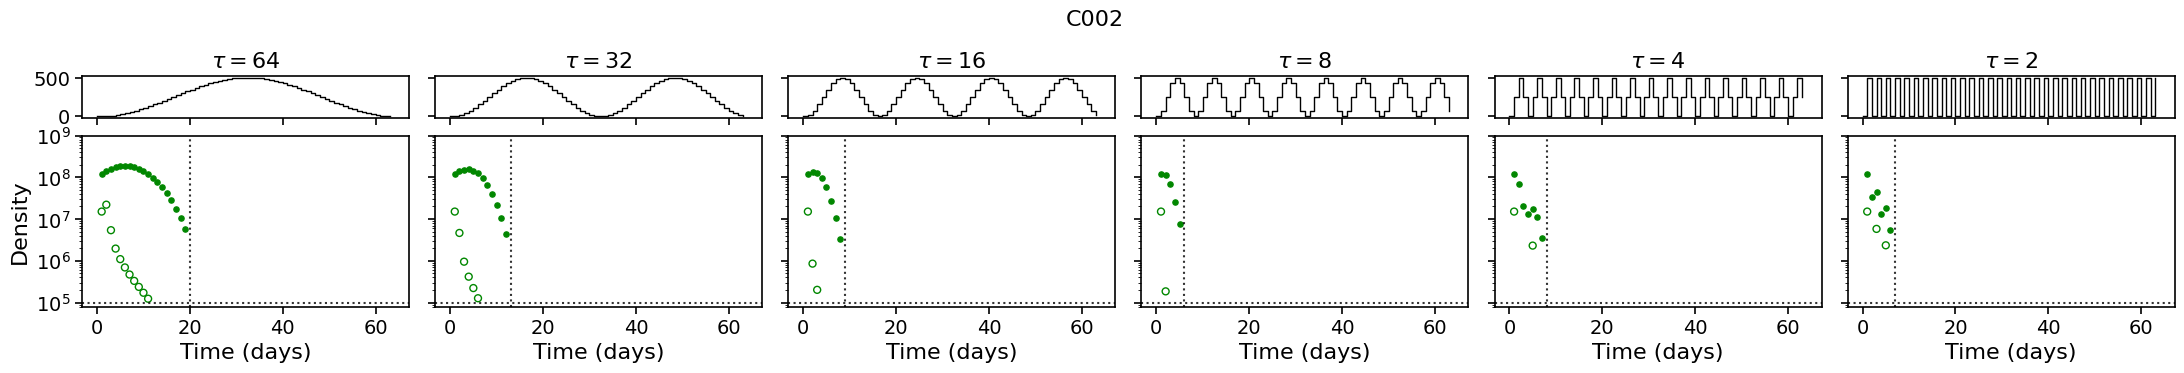

Plotting strain: C006


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/C006_periodic_signal_and_density.png


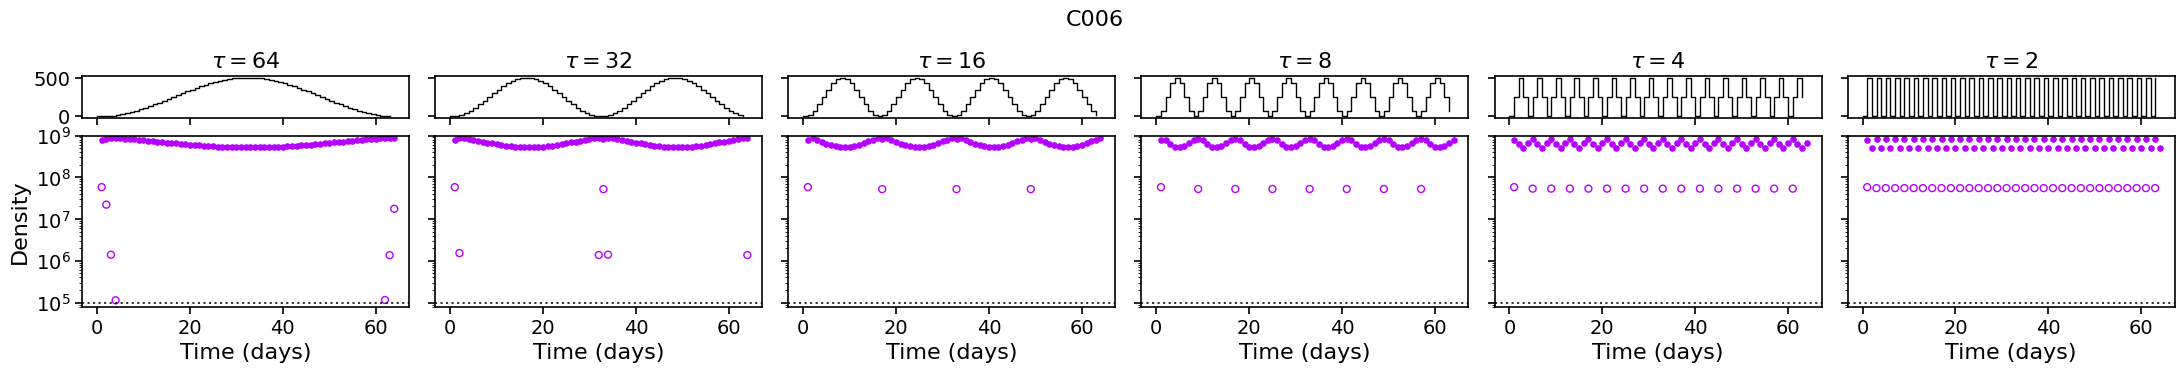

Plotting strain: C022


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/C022_periodic_signal_and_density.png


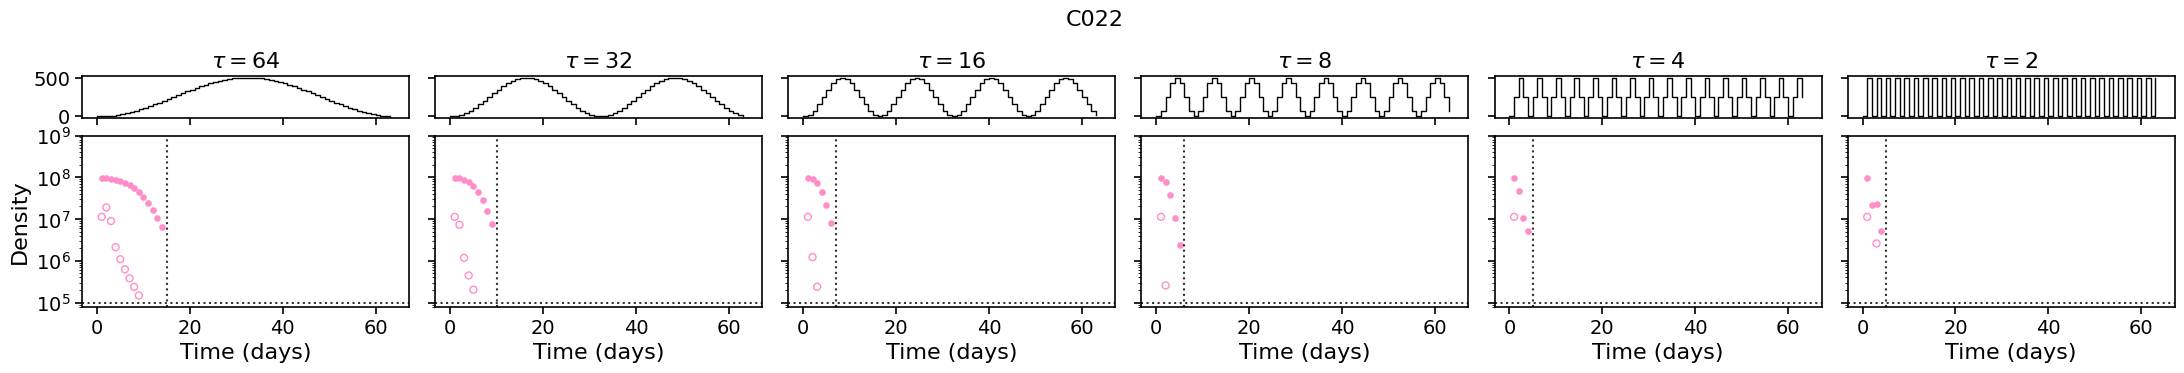

Plotting strain: C063


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/C063_periodic_signal_and_density.png


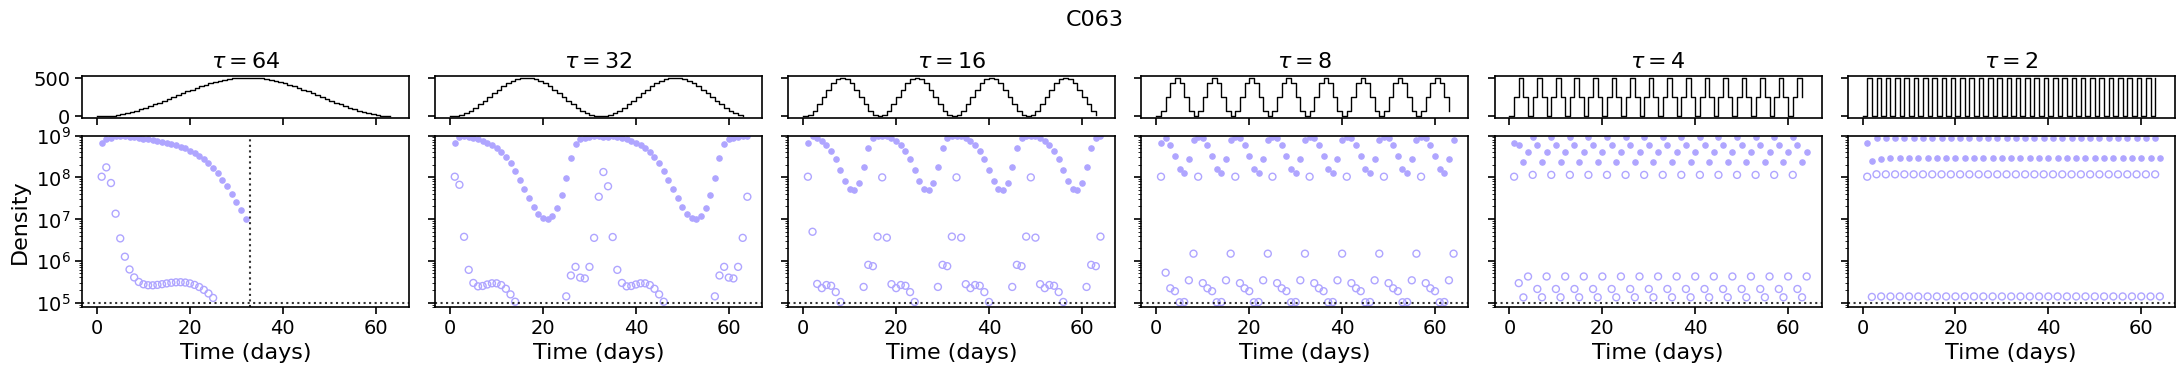

Plotting strain: C107


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/C107_periodic_signal_and_density.png


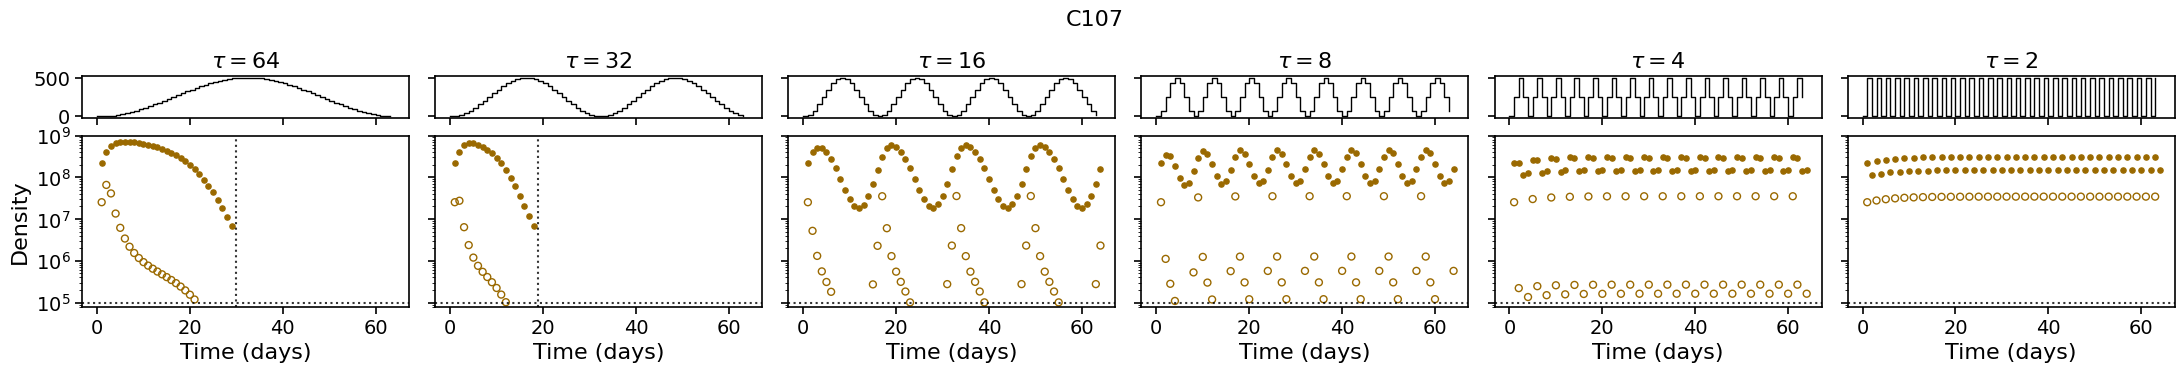

Plotting strain: C201


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/C201_periodic_signal_and_density.png


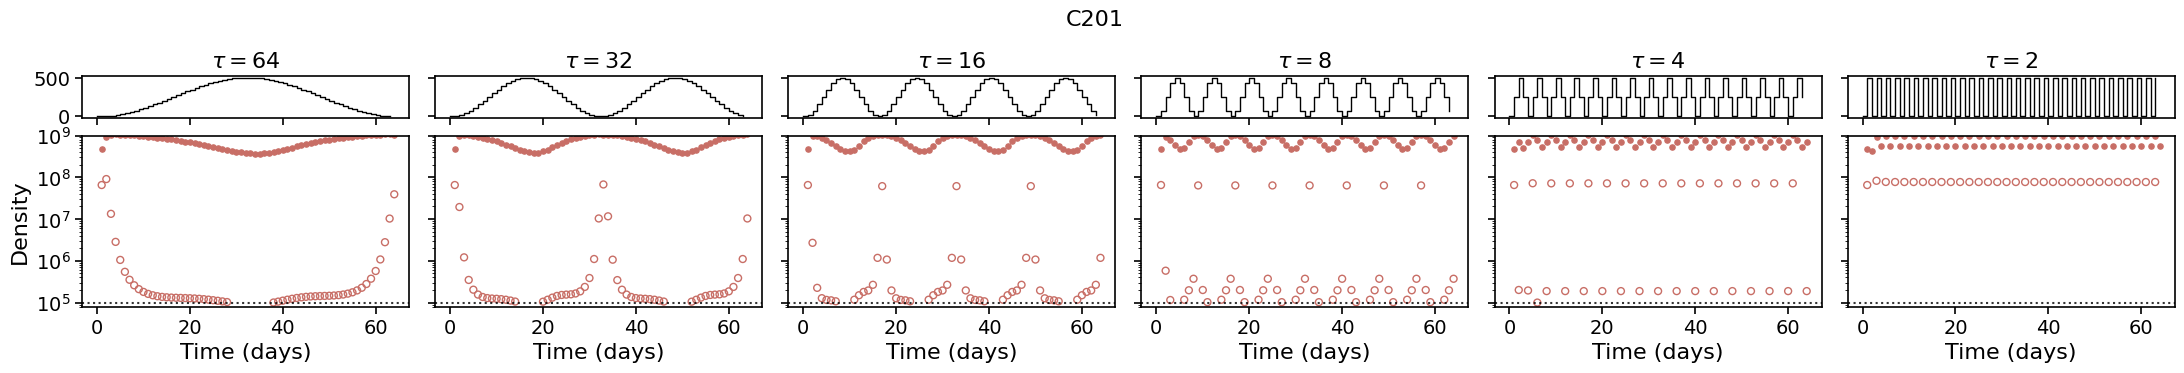

Plotting strain: C247


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/C247_periodic_signal_and_density.png


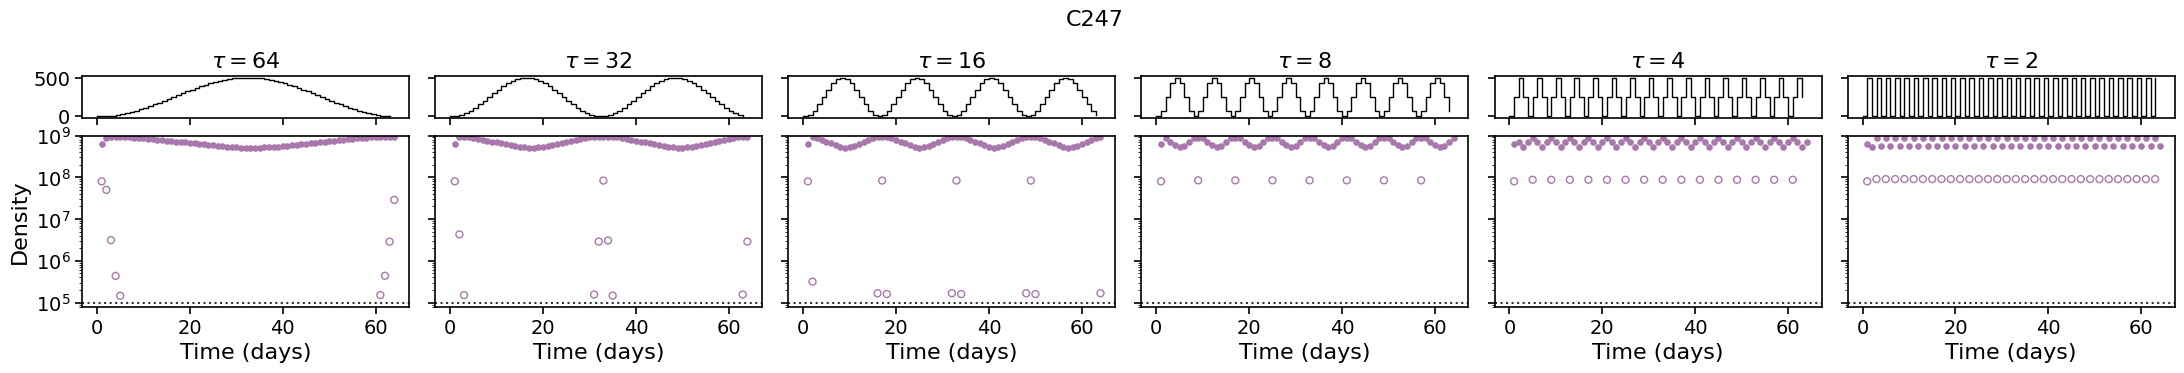

Plotting strain: C286


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/C286_periodic_signal_and_density.png


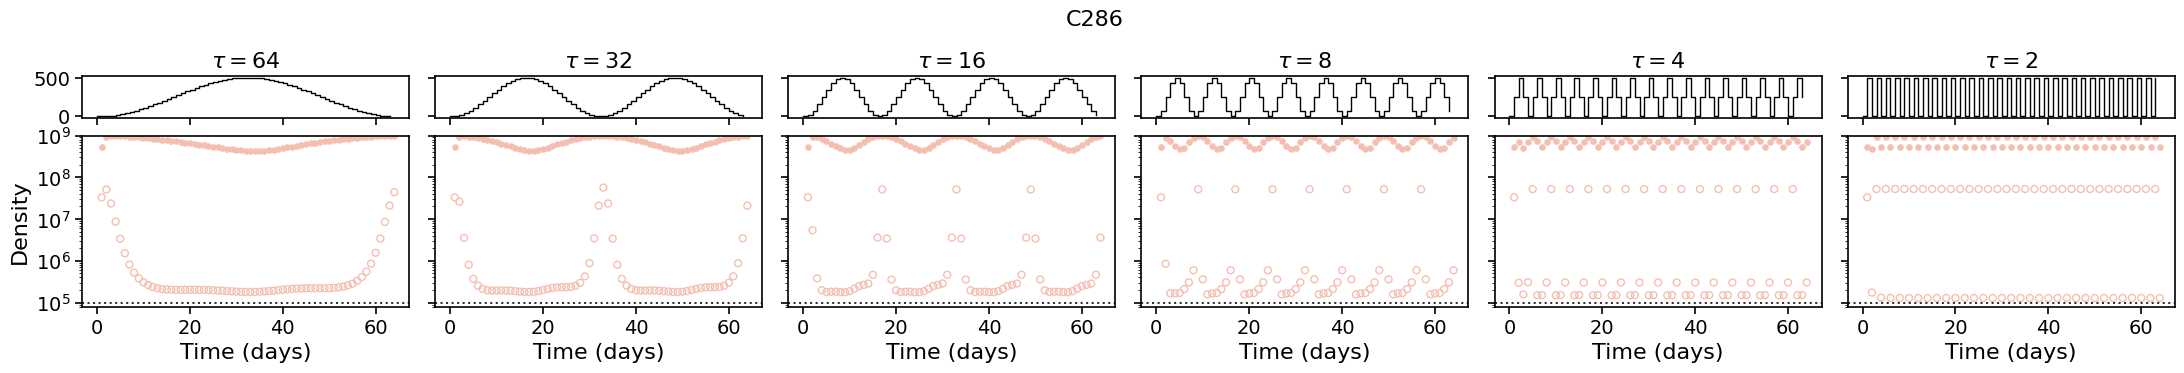

Plotting strain: C290


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/C290_periodic_signal_and_density.png


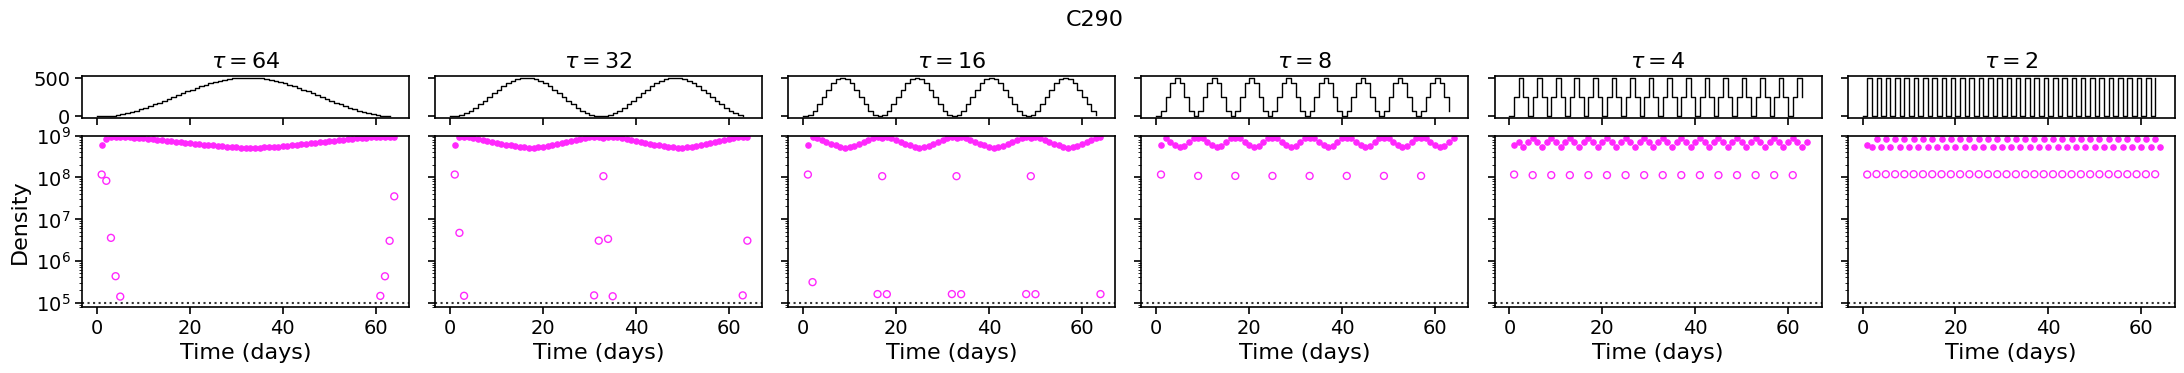

Plotting strain: C324


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/C324_periodic_signal_and_density.png


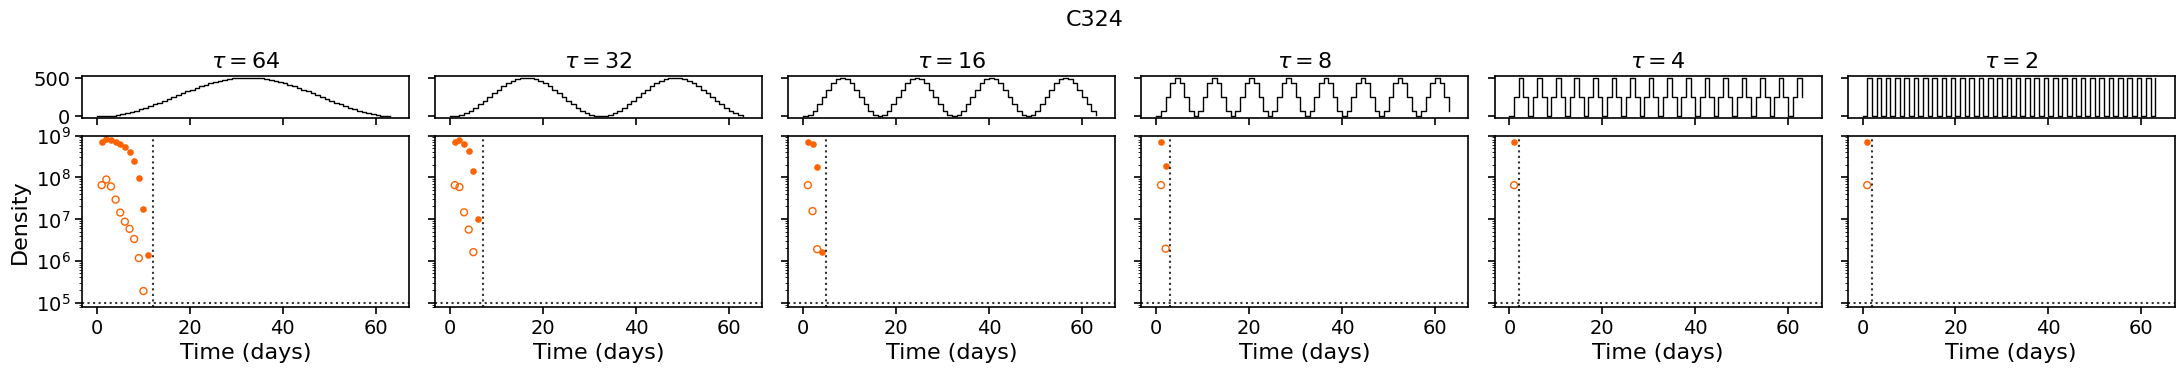

Plotting strain: K037


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/K037_periodic_signal_and_density.png


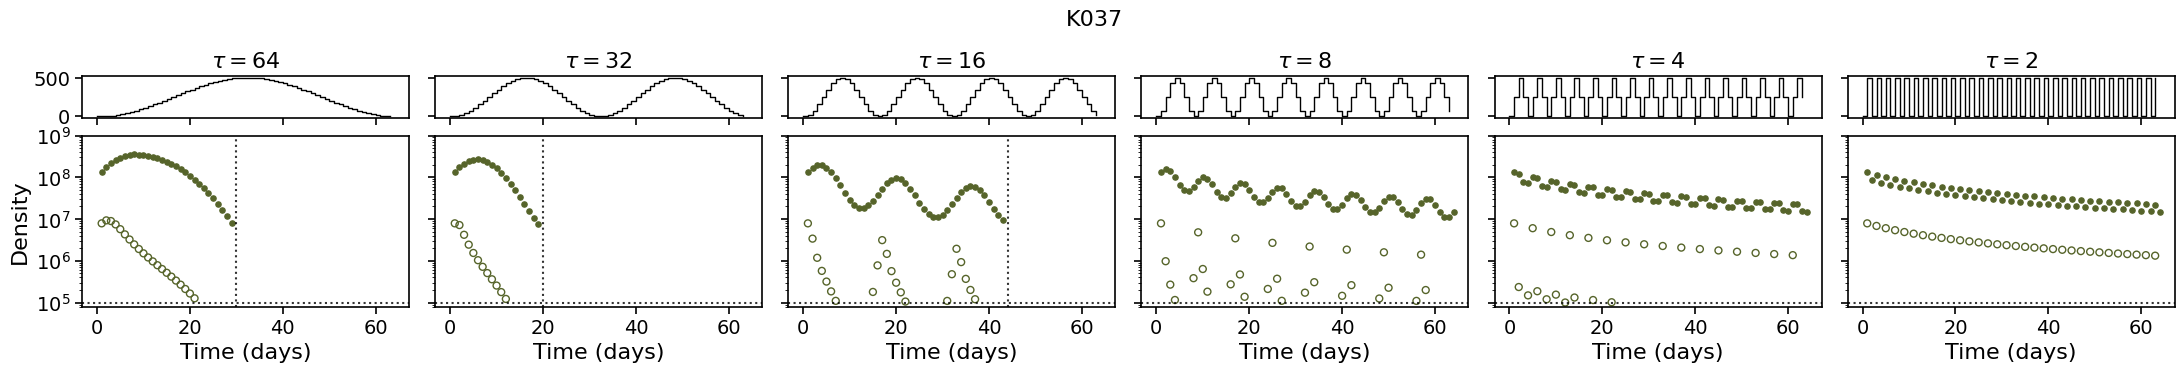

Plotting strain: K038


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/K038_periodic_signal_and_density.png


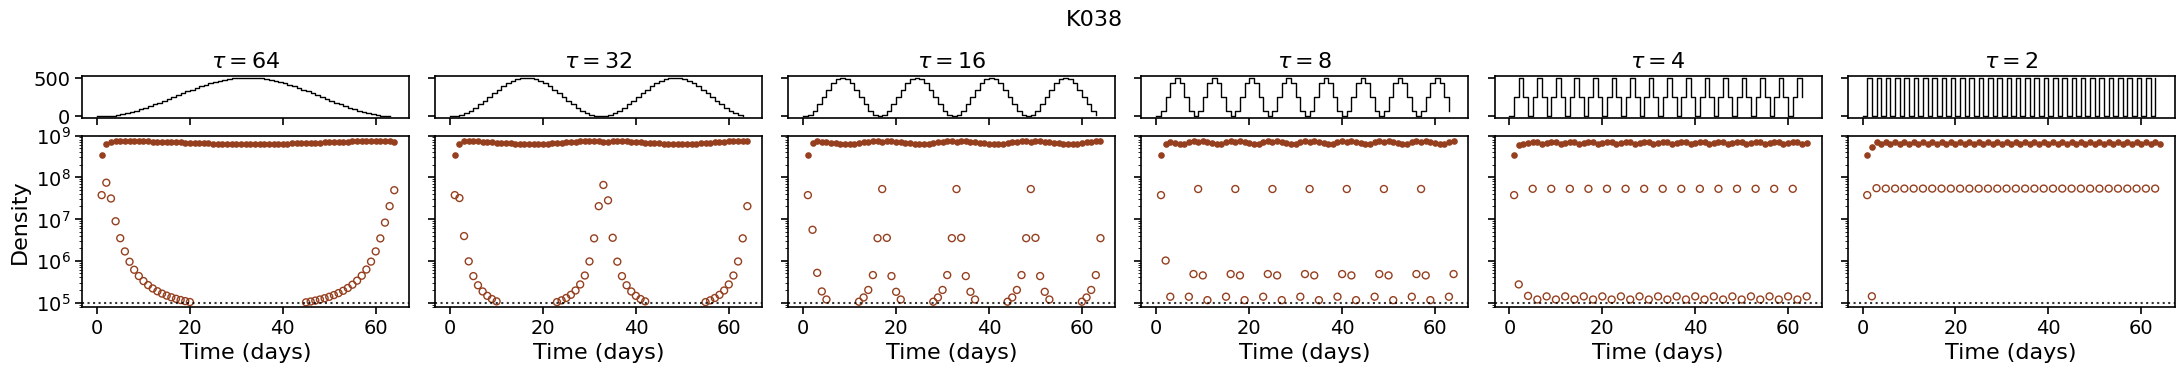

Plotting strain: K112


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/K112_periodic_signal_and_density.png


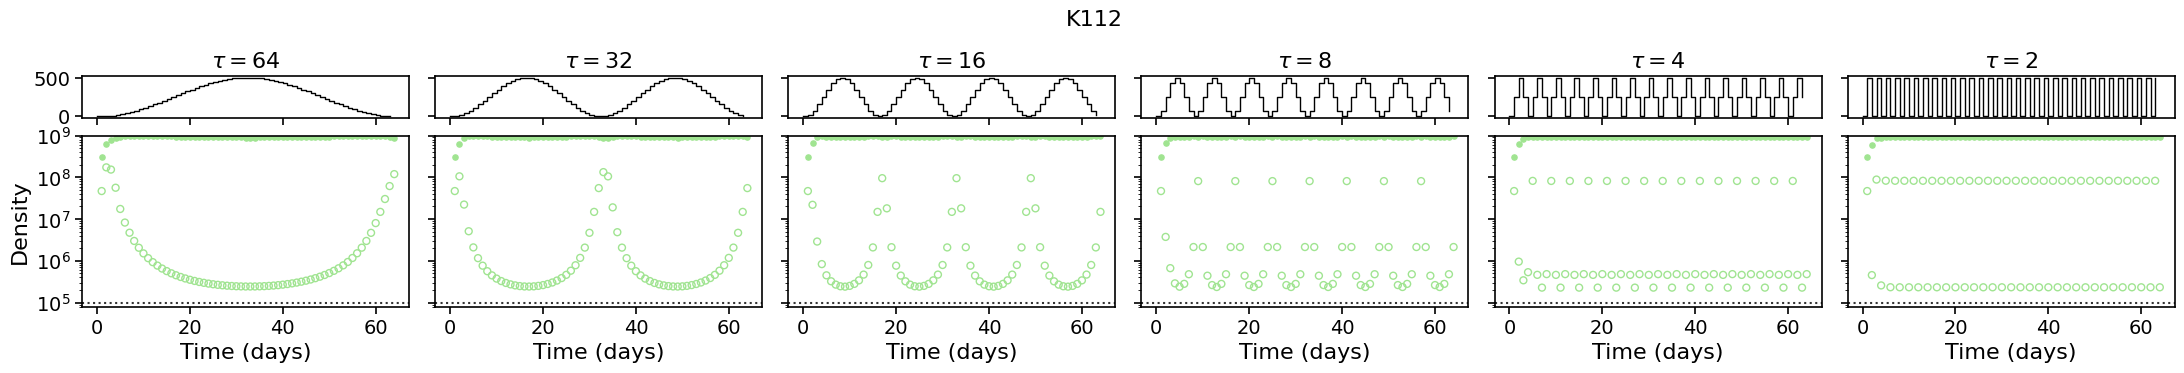

Plotting strain: K177


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/K177_periodic_signal_and_density.png


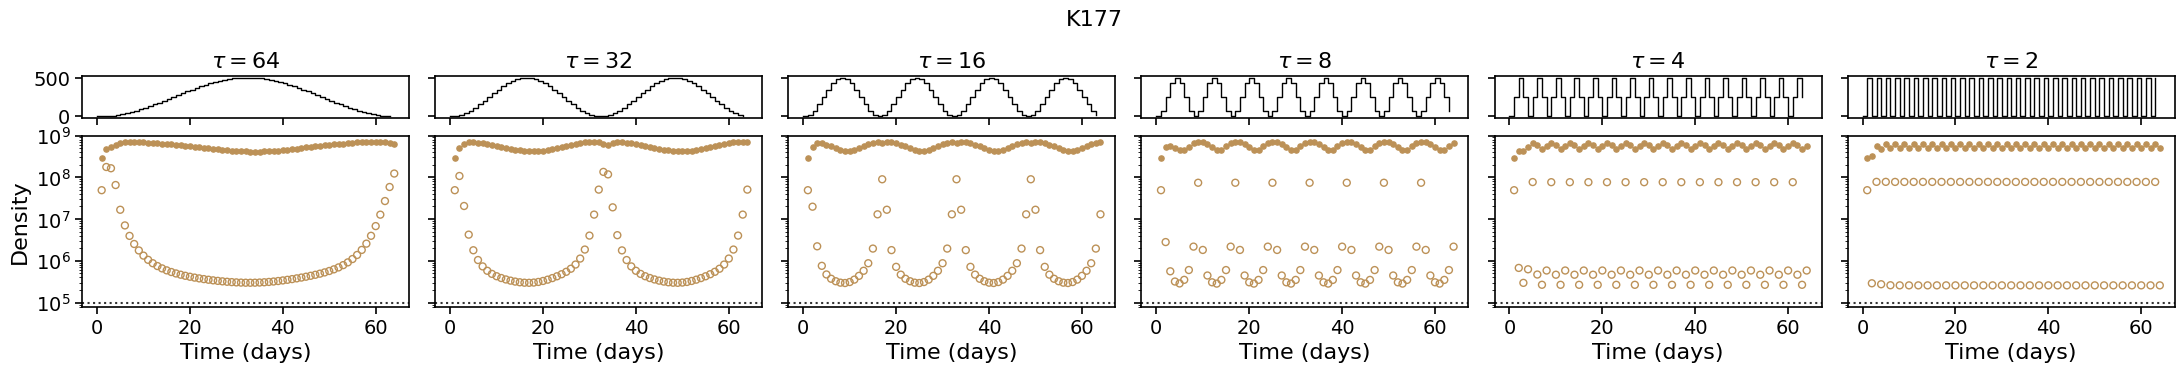

Plotting strain: K209


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/K209_periodic_signal_and_density.png


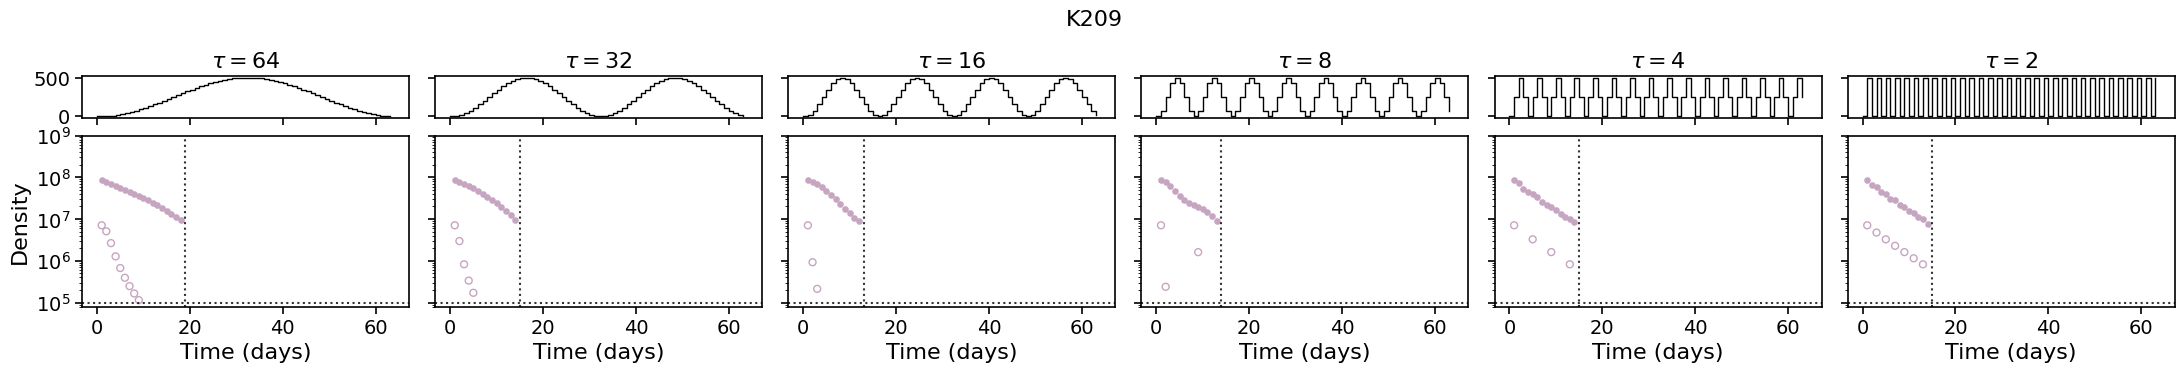

Plotting strain: K213


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/K213_periodic_signal_and_density.png


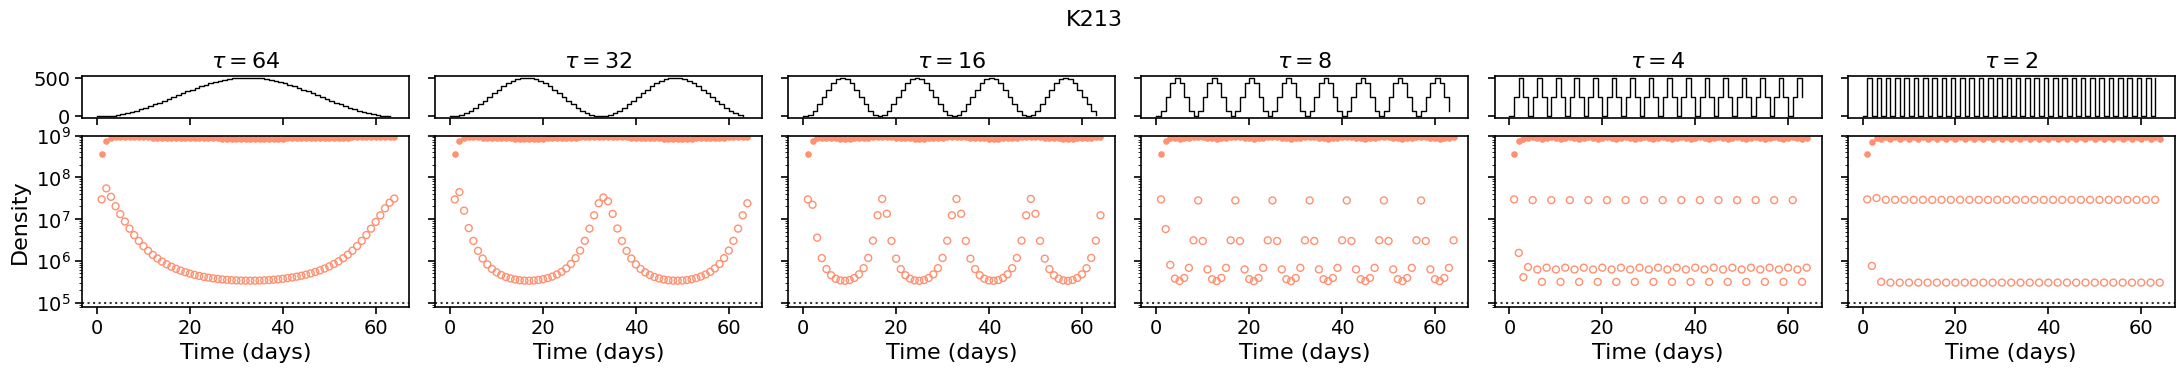

Plotting strain: K216


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/K216_periodic_signal_and_density.png


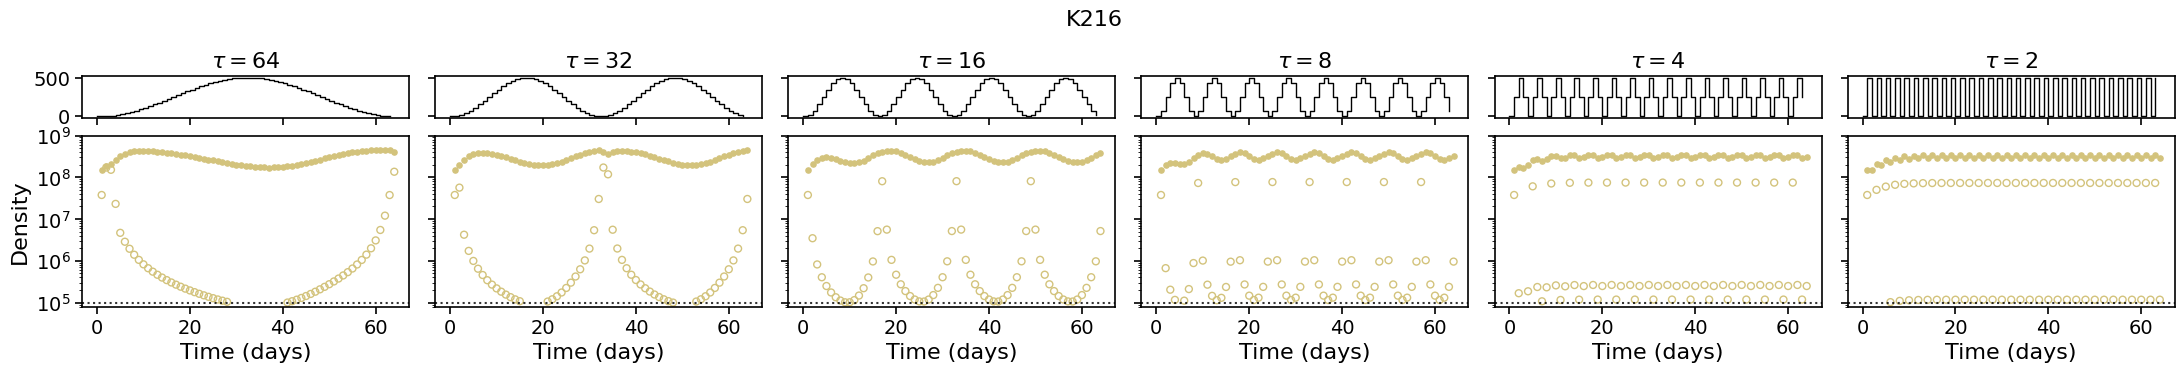

Plotting strain: K225


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/K225_periodic_signal_and_density.png


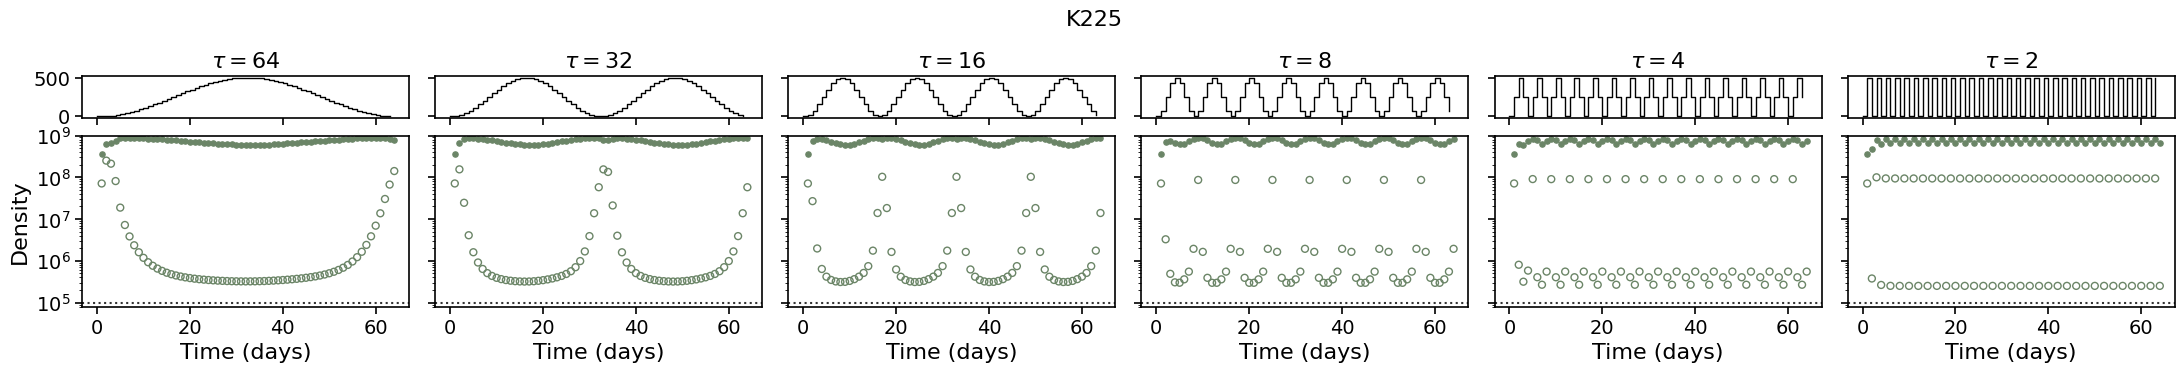

Plotting strain: K248


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/K248_periodic_signal_and_density.png


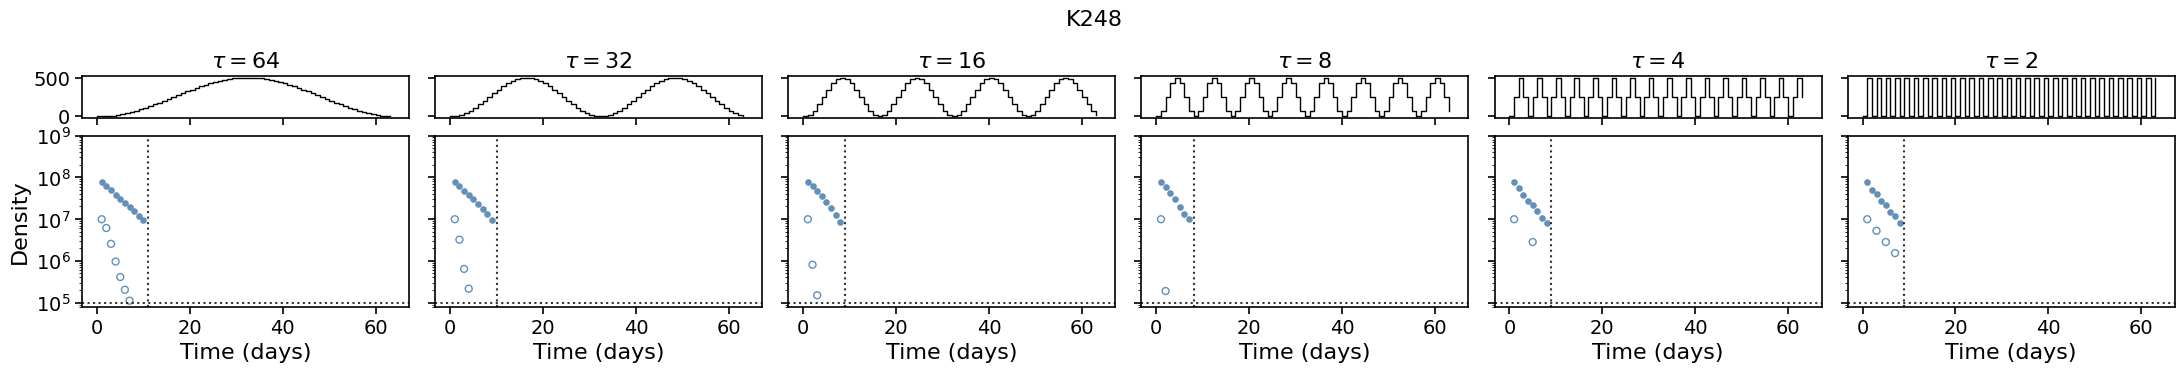

Plotting strain: K253


/tmp/ipykernel_7645/3284653435.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/K253_periodic_signal_and_density.png


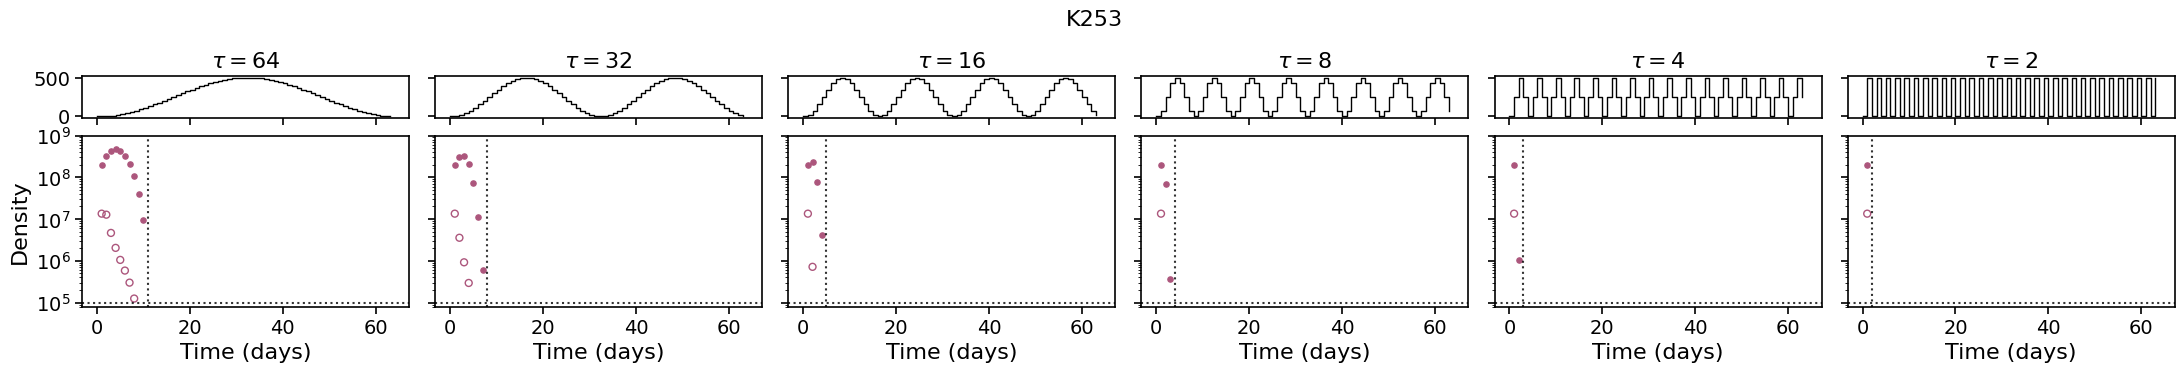

In [ ]:
taus_to_plot = tau_values #[0,2,4,8,16,32,64]

all_periodic_density_dfs = {}

for strain_id in strain_list:

    print(f"Plotting strain: {strain_id}")

    try:
        fig, axes, periodic_density_df = plot_periodic_signal_and_density_subplots(
            strain_id,
            exp4_single_loaded_results,
            model_params=model_params,
            tau_values=taus_to_plot,
            num_days=num_days,
            Amin=Amin,
            Amax=Amax,
            density_extinction_threshold=extinction_threshold,
            save_path=(
                exp4_single_fig_path
                / f"{strain_id}_periodic_signal_and_density.png"
            ),
            connect_points=True,
        )

        plt.show()
        all_periodic_density_dfs[strain_id] = periodic_density_df



    except ValueError as e:
        print(f"Skipping {strain_id}: {e}")


In [ ]:
# Build time-to-extinction / persistence table for periodic single-strain simulations.
#
# One row per strain x tau environment.
# Uses only the "total" population extinction result.

periodic_total_extinction_df = exp4_single_extinction_df[
    exp4_single_extinction_df["population"] == "total"
].copy()

# Make sure went_extinct is boolean
if periodic_total_extinction_df["went_extinct"].dtype == object:
    periodic_total_extinction_df["went_extinct"] = (
        periodic_total_extinction_df["went_extinct"]
        .astype(str)
        .str.lower()
        .map({"true": True, "false": False})
    )

periodic_total_extinction_df["survived"] = ~periodic_total_extinction_df["went_extinct"]

# Persistence time:
# - extinct: extinction_day
# - not extinct: full experiment duration
periodic_total_extinction_df["persistence_time"] = np.where(
    periodic_total_extinction_df["went_extinct"],
    periodic_total_extinction_df["extinction_day"],
    num_days,
)

# Time-to-extinction only among extinct simulations
periodic_total_extinction_df["time_to_extinction_if_extinct"] = np.where(
    periodic_total_extinction_df["went_extinct"],
    periodic_total_extinction_df["extinction_day"],
    np.nan,
)

# Standardize tau labels and order
periodic_total_extinction_df["tau_name"] = periodic_total_extinction_df["tau"].apply(
    format_tau_for_filename
)

periodic_total_extinction_df["tau_label"] = periodic_total_extinction_df["tau"].apply(
    format_tau_label
)

tau_order = [format_tau_for_filename(tau) for tau in tau_values]

periodic_total_extinction_df["tau_name"] = pd.Categorical(
    periodic_total_extinction_df["tau_name"],
    categories=tau_order,
    ordered=True,
)

periodic_total_extinction_df = periodic_total_extinction_df.sort_values(
    ["tau_name", "strain_id"]
).reset_index(drop=True)

periodic_time_metrics_file = (
    exp4_single_run_path
    / "experiment4_single_strain_periodic_time_metrics.csv"
)

periodic_total_extinction_df.to_csv(periodic_time_metrics_file, index=False)

display(periodic_total_extinction_df.head())

print("Saved periodic time metrics to:", periodic_time_metrics_file)


,run_id,strain,population,density_col,went_extinct,extinction_day,extinction_index,initial_density,final_density,max_density,...,tau,tau_label,tau_name,Amin,Amax,save_file,tau_order,survived,persistence_time,time_to_extinction_if_extinct
0,exp4_singleStrain_C001_periodic_Amin0_Amax512_...,C001,total,Btotal_final,True,5.0,4.0,2.745812e+08,0.000000e+00,3.841759e+08,...,64,$\tau=64$,tau64,0.0,512.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0,False,5.0,5.0
1,exp4_singleStrain_C002_periodic_Amin0_Amax512_...,C002,total,Btotal_final,True,20.0,19.0,1.353783e+08,0.000000e+00,1.860659e+08,...,64,$\tau=64$,tau64,0.0,512.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0,False,20.0,20.0
2,exp4_singleStrain_C006_periodic_Amin0_Amax512_...,C006,total,Btotal_final,False,NaN,NaN,8.244290e+08,8.714406e+08,8.714406e+08,...,64,$\tau=64$,tau64,0.0,512.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0,True,64.0,NaN
3,exp4_singleStrain_C011_periodic_Amin0_Amax512_...,C011,total,Btotal_final,True,6.0,5.0,7.024048e+08,0.000000e+00,7.024048e+08,...,64,$\tau=64$,tau64,0.0,512.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0,False,6.0,6.0
4,exp4_singleStrain_C012_periodic_Amin0_Amax512_...,C012,total,Btotal_final,True,33.0,32.0,2.785695e+08,0.000000e+00,6.613558e+08,...,64,$\tau=64$,tau64,0.0,512.0,/content/drive/MyDrive/SYNC_Projects/plasmidNo...,0,False,33.0,33.0


Saved periodic time metrics to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T64/experiment4_periodic_environments/single_strain_periodic/experiment4_single_strain_periodic_time_metrics.csv


In [ ]:
def summarize_time_metrics_by_tau(
    df,
    *,
    tau_values,
    strain_ids=None,
    strain_col="strain_id",
    tau_col="tau",
    extinction_col="went_extinct",
):
    """
    Summarize time-to-extinction and persistence metrics by periodic environment.

    One row per tau/environment.

    Error bars represent variation across strains.
    """

    subset_df = df.copy()

    if strain_ids is not None:
        if isinstance(strain_ids, str):
            strain_ids = [strain_ids]

        subset_df = subset_df[
            subset_df[strain_col].isin(strain_ids)
        ].copy()

    if len(subset_df) == 0:
        print("No rows found for selected strain subset.")
        return pd.DataFrame(), subset_df

    if subset_df[extinction_col].dtype == object:
        subset_df[extinction_col] = (
            subset_df[extinction_col]
            .astype(str)
            .str.lower()
            .map({"true": True, "false": False})
        )

    if "survived" not in subset_df.columns:
        subset_df["survived"] = ~subset_df[extinction_col]

    if "tau_name" not in subset_df.columns:
        subset_df["tau_name"] = subset_df[tau_col].apply(format_tau_for_filename)

    if "tau_label" not in subset_df.columns:
        subset_df["tau_label"] = subset_df[tau_col].apply(format_tau_label)

    tau_order = [format_tau_for_filename(tau) for tau in tau_values]

    summary_df = (
        subset_df
        .groupby(["tau_name", "tau_label"], observed=True)
        .agg(
            n_simulations=(extinction_col, "size"),
            n_extinct=(extinction_col, "sum"),
            n_survived=("survived", "sum"),

            fraction_extinct=(extinction_col, "mean"),
            fraction_without_extinction=("survived", "mean"),
            percent_surviving=("survived", lambda x: 100 * x.mean()),

            mean_time_to_extinction_if_extinct=("time_to_extinction_if_extinct", "mean"),
            median_time_to_extinction_if_extinct=("time_to_extinction_if_extinct", "median"),
            sem_time_to_extinction_if_extinct=("time_to_extinction_if_extinct", "sem"),

            mean_persistence_time=("persistence_time", "mean"),
            median_persistence_time=("persistence_time", "median"),
            sem_persistence_time=("persistence_time", "sem"),

            mean_final_density=("final_density", "mean"),
            median_final_density=("final_density", "median"),
            sem_final_density=("final_density", "sem"),
        )
        .reset_index()
    )

    # Binomial SEM for survival fraction and percent survival
    p = summary_df["fraction_without_extinction"]
    n = summary_df["n_simulations"]

    summary_df["sem_fraction_without_extinction"] = np.sqrt(
        p * (1 - p) / n
    )

    summary_df["sem_percent_surviving"] = (
        100 * summary_df["sem_fraction_without_extinction"]
    )

    summary_df["tau_name"] = pd.Categorical(
        summary_df["tau_name"],
        categories=tau_order,
        ordered=True,
    )

    summary_df = summary_df.sort_values("tau_name").reset_index(drop=True)

    return summary_df, subset_df

In [ ]:
periodic_time_summary, periodic_time_subset = summarize_time_metrics_by_tau(
    periodic_total_extinction_df,
    tau_values=tau_values,
)

display(periodic_time_summary)

,tau_name,tau_label,n_simulations,n_extinct,n_survived,fraction_extinct,fraction_without_extinction,percent_surviving,mean_time_to_extinction_if_extinct,median_time_to_extinction_if_extinct,sem_time_to_extinction_if_extinct,mean_persistence_time,median_persistence_time,sem_persistence_time,mean_final_density,median_final_density,sem_final_density,sem_fraction_without_extinction,sem_percent_surviving
0,tau64,$\tau=64$,50,28,22,0.56,0.44,44.0,19.464286,19.5,1.915187,39.06,33.0,3.332513,3.766949e+08,0.000000e+00,6.182765e+07,0.070200,7.019972
1,tau32,$\tau=32$,50,26,24,0.52,0.48,48.0,12.153846,11.5,1.200887,37.04,23.0,3.751676,4.088242e+08,0.000000e+00,6.215336e+07,0.070654,7.065409
2,tau16,$\tau=16$,50,22,28,0.44,0.56,56.0,8.863636,6.5,1.809422,39.74,64.0,3.988024,4.284703e+08,4.070755e+08,5.970485e+07,0.070200,7.019972
3,tau8,$\tau=8$,50,20,30,0.40,0.60,60.0,5.850000,4.0,0.892292,40.74,64.0,4.084796,3.936545e+08,2.990574e+08,5.514243e+07,0.069282,6.928203
4,tau4,$\tau=4$,50,19,31,0.38,0.62,62.0,6.842105,3.0,1.535664,42.28,64.0,4.004695,3.319878e+08,2.640017e+08,4.711881e+07,0.068644,6.864401
5,tau2,$\tau=2$,50,19,31,0.38,0.62,62.0,6.789474,2.0,1.672934,42.26,64.0,4.015969,2.883446e+08,2.389790e+08,4.169551e+07,0.068644,6.864401


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/periodic_percent_surviving_strains_strip_sem.png


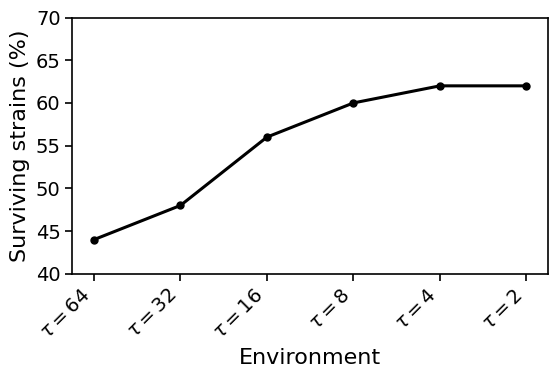

,tau_name,n,fraction_surviving,percent_surviving,sem_percent_surviving
0,tau64,50,0.44,44.0,7.019972
1,tau32,50,0.48,48.0,7.065409
2,tau16,50,0.56,56.0,7.019972
3,tau8,50,0.60,60.0,6.928203
4,tau4,50,0.62,62.0,6.864401
5,tau2,50,0.62,62.0,6.864401


In [ ]:
def plot_survival_percent_by_tau(
    df,
    *,
    tau_values,
    save_path=None,
    title="",
):
    """
    Plot survival across periodic environments.

    Individual points:
        each strain, 0 = extinct, 100 = survived

    Black line:
        mean percent survival

    Error bars:
        binomial SEM across strains
    """

    plot_df = df.copy()

    if "tau_name" not in plot_df.columns:
        plot_df["tau_name"] = plot_df["tau"].apply(format_tau_for_filename)

    if "tau_label" not in plot_df.columns:
        plot_df["tau_label"] = plot_df["tau"].apply(format_tau_label)

    if plot_df["survived"].dtype == object:
        plot_df["survived"] = (
            plot_df["survived"]
            .astype(str)
            .str.lower()
            .map({"true": True, "false": False})
        )

    plot_df["survival_percent"] = 100 * plot_df["survived"].astype(float)

    tau_name_order = [format_tau_for_filename(tau) for tau in tau_values]
    tau_label_map = {
        format_tau_for_filename(tau): format_tau_label(tau)
        for tau in tau_values
    }

    plot_df["tau_name"] = pd.Categorical(
        plot_df["tau_name"],
        categories=tau_name_order,
        ordered=True,
    )

    plot_df = plot_df.sort_values("tau_name").reset_index(drop=True)

    summary_df = (
        plot_df
        .groupby("tau_name", observed=True)
        .agg(
            n=("survived", "size"),
            fraction_surviving=("survived", "mean"),
            percent_surviving=("survival_percent", "mean"),
        )
        .reset_index()
    )

    p = summary_df["fraction_surviving"]
    n = summary_df["n"]

    summary_df["sem_percent_surviving"] = 100 * np.sqrt(
        p * (1 - p) / n
    )

    x = np.arange(len(tau_name_order))

    fig, ax = plt.subplots(figsize=(5.8, 4.0))

    rng_plot = np.random.default_rng(123)



    ax.plot(
        x,
        summary_df["percent_surviving"],
        color="black",
        linewidth=2.2,
        marker="o",
        markersize=5,
        markerfacecolor="black",
        markeredgecolor="black",
        zorder=5,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [tau_label_map[t] for t in tau_name_order],
        rotation=45,
        ha="right",
    )

    ax.set_ylim(40, 70)
    ax.set_xlabel("Environment")
    ax.set_ylabel("Surviving strains (%)")
    ax.set_title(title)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, ax, summary_df

fig, ax, survival_summary_df = plot_survival_percent_by_tau(
    periodic_time_subset,
    tau_values=tau_values,
    save_path=exp4_single_fig_path / "periodic_percent_surviving_strains_strip_sem.png",
)

plt.show()

display(survival_summary_df)

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_time_metric_violins_by_tau(
    df,
    *,
    tau_values,
    metric_col,
    ylabel,
    title,
    strain_id=None,
    model_params=None,
    save_path=None,
):
    """
    Plot violin distributions of a time metric across periodic environments.

    Robust to missing values:
    - skips tau values with no valid observations
    - if no valid observations exist, returns an empty annotated plot
    - adds a dashed black line through the mean of each group
    """

    plot_df = df.copy()

    # Keep only rows with a valid metric
    plot_df = plot_df[
        plot_df[metric_col].notna()
    ].copy()

    # Make sure tau_name and tau_label exist
    if "tau_name" not in plot_df.columns:
        plot_df["tau_name"] = plot_df["tau"].apply(format_tau_for_filename)

    if "tau_label" not in plot_df.columns:
        plot_df["tau_label"] = plot_df["tau"].apply(format_tau_label)

    tau_name_order = [format_tau_for_filename(tau) for tau in tau_values]
    tau_label_map = {
        format_tau_for_filename(tau): format_tau_label(tau)
        for tau in tau_values
    }

    # Preserve requested tau order
    plot_df["tau_name"] = pd.Categorical(
        plot_df["tau_name"],
        categories=tau_name_order,
        ordered=True,
    )

    plot_df = plot_df.sort_values("tau_name").reset_index(drop=True)

    # Build values per tau, skipping empty groups
    values = []
    labels = []
    positions = []
    mean_values = []

    for i, tau_name in enumerate(tau_name_order):
        vals = (
            plot_df.loc[plot_df["tau_name"] == tau_name, metric_col]
            .dropna()
            .astype(float)
            .to_numpy()
        )

        if len(vals) == 0:
            continue

        values.append(vals)
        labels.append(tau_label_map[tau_name])
        positions.append(i)
        mean_values.append(np.mean(vals))

    # Get strain color
    if strain_id is not None and model_params is not None:
        strain_color_map = make_strain_color_map(
            [strain_id],
            model_params=model_params,
            strain_col="strain",
            color_col="color",
        )
        violin_color = strain_color_map.get(str(strain_id), "#3784BA")
    else:
        violin_color = "#3784BA"

    fig, ax = plt.subplots(figsize=(6.5, 4.0))

    # If no values exist, show a useful empty plot
    if len(values) == 0:
        ax.text(
            0.5,
            0.5,
            f"No valid values for {metric_col}",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

        ax.set_xticks(range(len(tau_name_order)))
        ax.set_xticklabels(
            [tau_label_map[t] for t in tau_name_order],
            rotation=45,
            ha="right",
        )
        ax.set_ylabel(ylabel)
        ax.set_title(title)

        fig.tight_layout()

        if save_path is not None:
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
            print("Saved empty figure to:", save_path)

        return fig, ax

    # Violin plot
    parts = ax.violinplot(
        values,
        positions=positions,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )

    for body in parts["bodies"]:
        body.set_facecolor(violin_color)
        body.set_edgecolor("#3784BA")
        body.set_alpha(0.45)

    if "cmedians" in parts:
        parts["cmedians"].set_color("#3784BA")
        parts["cmedians"].set_linewidth(1.5)

    # Add individual points
    rng_plot = np.random.default_rng(123)

    for pos, vals in zip(positions, values):
        jitter = rng_plot.normal(0, 0.04, size=len(vals))

        ax.scatter(
            np.full(len(vals), pos) + jitter,
            vals,
            s=18,
            alpha=0.2,
            color="k",
            edgecolors="none",
        )

    # Add dashed black line through the means
    ax.plot(
        positions,
        mean_values,
        color="black",
        linestyle="--",
        linewidth=2,
        marker="o",
        markersize=5,
        zorder=5,
    )

    ax.set_xticks(range(len(tau_name_order)))
    ax.set_xticklabels(
        [tau_label_map[t] for t in tau_name_order],
        rotation=45,
        ha="right",
    )

    ax.set_ylabel(ylabel)
    ax.set_title(title)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, ax

Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/periodic_persistence_time_violin.png


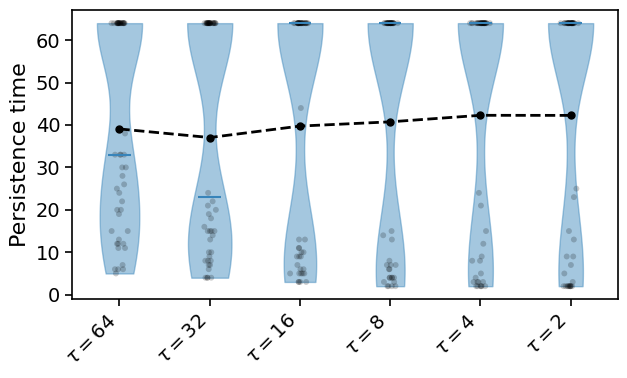

In [ ]:
fig, ax = plot_time_metric_violins_by_tau(
    periodic_time_subset,
    tau_values=tau_values,
    metric_col="persistence_time",
    ylabel="Persistence time",
    title="",
    save_path=exp4_single_fig_path / "periodic_persistence_time_violin.png",
)

plt.show()

Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/periodic_time_to_extinction_violin.png


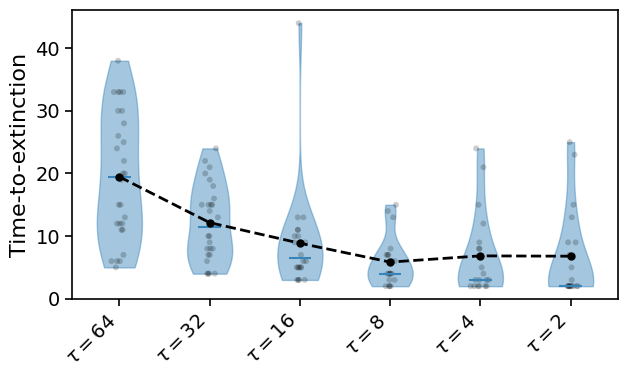

In [ ]:
fig, ax = plot_time_metric_violins_by_tau(
    periodic_time_subset,
    tau_values=tau_values,
    metric_col="time_to_extinction_if_extinct",
    ylabel="Time-to-extinction",
    title="",
    save_path=exp4_single_fig_path / "periodic_time_to_extinction_violin.png",
)

plt.show()

Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/periodic_final_density_violin.png


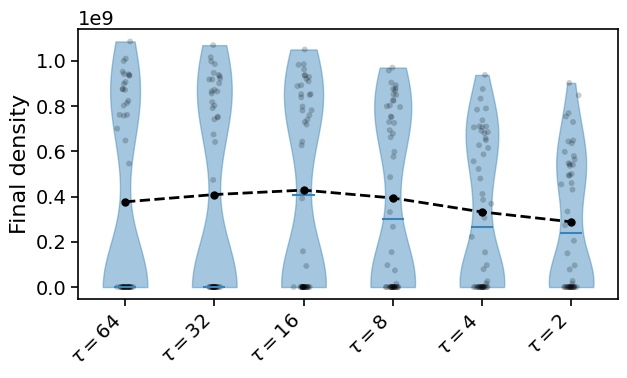

In [ ]:
fig, ax = plot_time_metric_violins_by_tau(
    periodic_time_subset,
    tau_values=tau_values,
    metric_col="final_density",
    ylabel="Final density",
    title="",
    save_path=exp4_single_fig_path / "periodic_final_density_violin.png",
)

plt.show()

In [ ]:
def plot_periodic_single_strain_landscape(
    exp4_single_df,
    *,
    tau_values=None,
    strain_order=None,
    save_path=None,
):
    """
    Plot a period-response landscape for single-strain periodic simulations.

    Panels:
    1. survival / extinction
    2. final plasmid fraction
    3. final bacterial density

    Rows = strains
    Columns = tau values
    """

    df = exp4_single_df.copy()

    if tau_values is None:
        tau_values = sorted(df["tau"].unique())
    else:
        tau_values = [tau for tau in tau_values if tau in df["tau"].unique()]

    if strain_order is None:
        # Order strains by mean survival, then mean final density
        strain_order = (
            df
            .groupby("strain_id")
            .agg(
                mean_survival=("survived", "mean"),
                mean_density=("bacterial_density", "mean"),
            )
            .sort_values(["mean_survival", "mean_density"], ascending=[False, False])
            .index
            .tolist()
        )

    df["tau"] = pd.Categorical(
        df["tau"],
        categories=tau_values,
        ordered=True,
    )

    df["strain_id"] = pd.Categorical(
        df["strain_id"],
        categories=strain_order,
        ordered=True,
    )

    df = df.sort_values(["strain_id", "tau"])

    survival_mat = (
        df
        .pivot(index="strain_id", columns="tau", values="survived")
        .reindex(index=strain_order, columns=tau_values)
        .astype(float)
    )

    plasmid_mat = (
        df
        .pivot(index="strain_id", columns="tau", values="plasmid_fraction")
        .reindex(index=strain_order, columns=tau_values)
    )

    density_mat = (
        df
        .pivot(index="strain_id", columns="tau", values="bacterial_density")
        .reindex(index=strain_order, columns=tau_values)
    )

    log_density_mat = np.log10(density_mat + 1)

    tau_labels = [
        "off" if tau == 0 else str(tau)
        for tau in tau_values
    ]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(13.0, max(4.0, 0.25 * len(strain_order))),
        sharey=True,
    )

    # ------------------------------------------------------------
    # Panel 1: survival
    # ------------------------------------------------------------
    im0 = axes[0].imshow(
        survival_mat,
        aspect="auto",
        interpolation="nearest",
        cmap='Blues',
        vmin=0,
        vmax=1,
    )

    axes[0].set_title("Survival")
    axes[0].set_xlabel(r"Period, $\tau$")
    axes[0].set_ylabel("Strain")

    cbar0 = fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    cbar0.set_ticks([0, 1])
    cbar0.set_ticklabels(["extinct", "survived"])

    # ------------------------------------------------------------
    # Panel 2: plasmid fraction
    # ------------------------------------------------------------
    im1 = axes[1].imshow(
        plasmid_mat,
        aspect="auto",
        interpolation="nearest",
        cmap='Blues',
        vmin=0,
        vmax=1,
    )

    axes[1].set_title("Final plasmid fraction")
    axes[1].set_xlabel(r"Period, $\tau$")

    cbar1 = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    cbar1.set_label("Plasmid fraction")

    # ------------------------------------------------------------
    # Panel 3: final density
    # ------------------------------------------------------------
    im2 = axes[2].imshow(
        log_density_mat,
        aspect="auto",
        cmap='Blues',
        interpolation="nearest",
    )

    axes[2].set_title(r"Final density, $\log_{10}(B+1)$")
    axes[2].set_xlabel(r"Period, $\tau$")

    cbar2 = fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    cbar2.set_label(r"$\log_{10}(B+1)$")

    # ------------------------------------------------------------
    # Shared axis formatting
    # ------------------------------------------------------------
    for ax in axes:
        ax.set_xticks(range(len(tau_values)))
        ax.set_xticklabels(tau_labels, rotation=45, ha="right")

        ax.set_yticks(range(len(strain_order)))
        ax.set_yticklabels(strain_order)

    fig.suptitle("Single strains under periodic environments", y=1.02)
    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    return fig, axes, {
        "survival": survival_mat,
        "plasmid_fraction": plasmid_mat,
        "log_density": log_density_mat,
    }


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/single_strain_periodic/single_strain_periodic_landscape.png


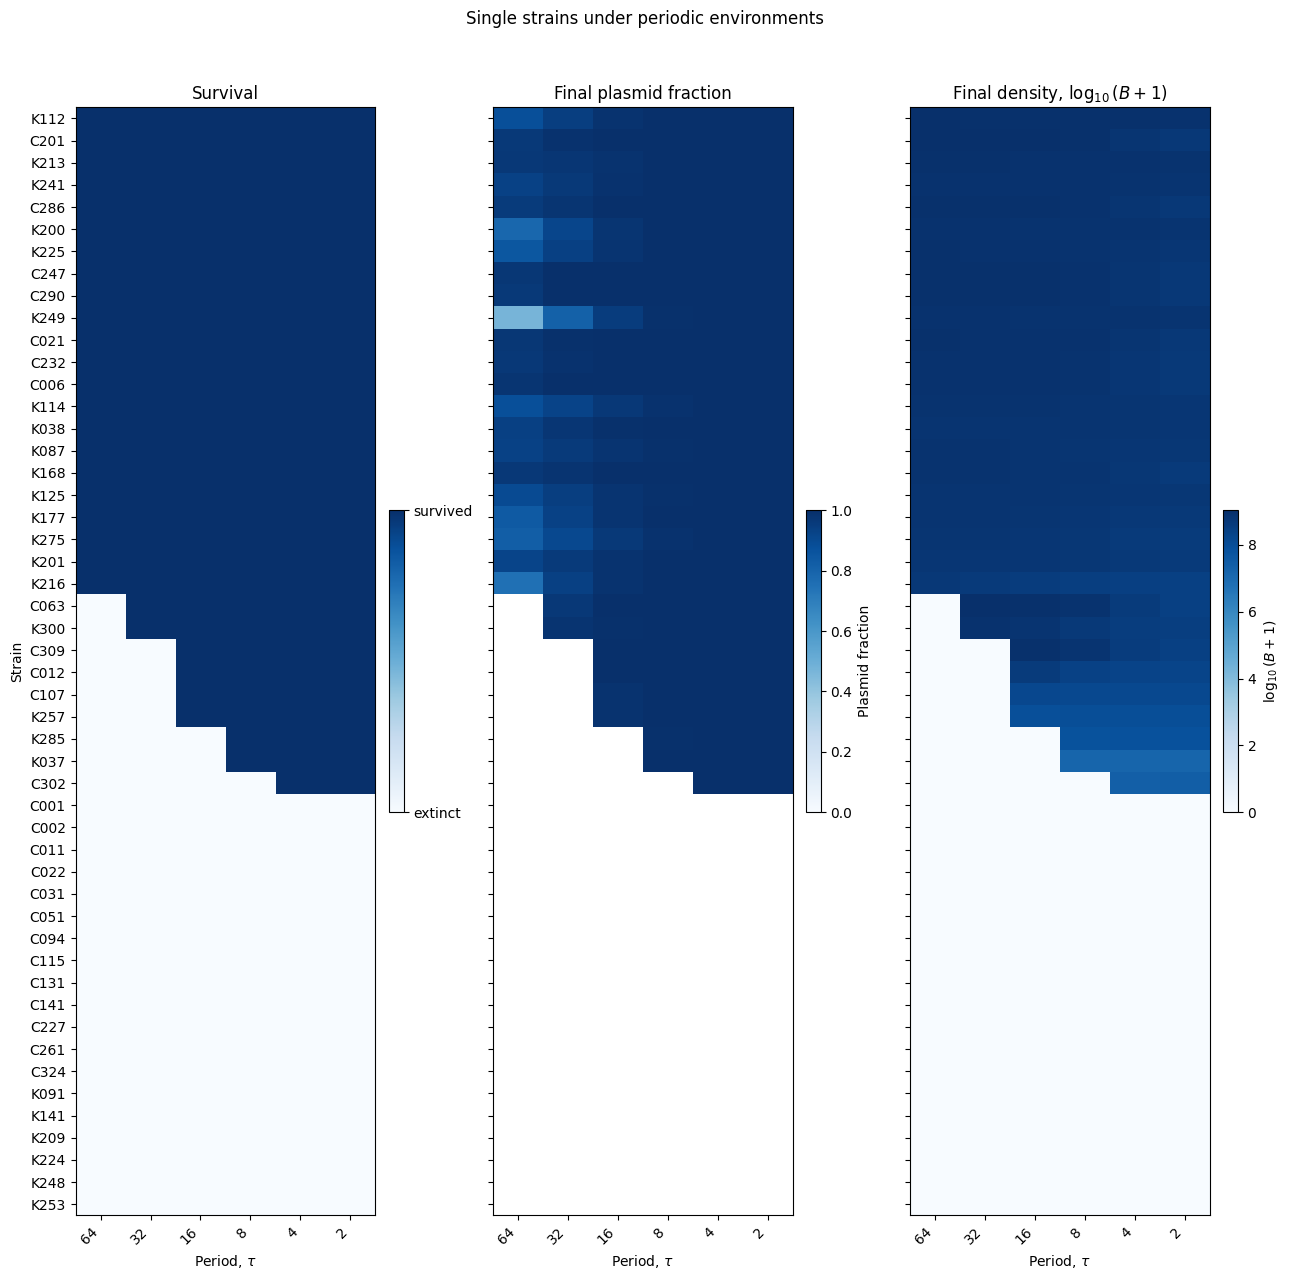

In [ ]:
taus_to_plot = tau_values #[0, 2, 4, 8, 16, 32, 64]

fig, axes, landscape_mats = plot_periodic_single_strain_landscape(
    exp4_single_df,
    tau_values=taus_to_plot,
    save_path=exp4_single_fig_path / "single_strain_periodic_landscape.png",
)


## Complete-community periodic simulations

The full selected community is then exposed to the same periodic treatment schedules. Community-level endpoint density, plasmid fraction, and strain-level composition show whether host heterogeneity buffers the single-strain extinction patterns.


In [ ]:
model_params_filtered = model_params[
    model_params["strain"].isin(selected_strains)
].copy()

strain_list = sorted(model_params_filtered["strain"].unique())

print("Number of selected strains:", len(strain_list))
print(strain_list)

display(model_params_filtered)
model_params=model_params_filtered.copy()


Number of selected strains: 20
['C002', 'C006', 'C022', 'C063', 'C107', 'C201', 'C247', 'C286', 'C290', 'C324', 'K037', 'K038', 'K112', 'K177', 'K209', 'K213', 'K216', 'K225', 'K248', 'K253']


,strain,display_name,species,color,r_p,affinity_p,k_star_p,r_0,affinity_0,k_star_0,lambda_loss,gamma,Km_p,Vmax_p,alpha_p,k_p,Km_0,Vmax_0,alpha_0,k_0
1,C002,PF_EC02,E,#018700,5.503865e+08,7.600000e-10,0.062500,6.786087e+08,6.650000e-10,0.000244,0.02,0.000000e+00,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.650000e-10,1.000000e-10,0.031250
2,C006,PF_EC03,E,#b500ff,8.900185e+08,7.600000e-10,0.062500,8.151455e+08,6.540000e-10,0.000122,0.02,0.000000e+00,1.0,7.600000e-10,1.000000e-12,0.000122,1.0,6.540000e-10,1.000000e-10,0.062500
6,C022,PF_EC07,E,#ff8ec8,1.039553e+09,3.790000e-10,0.062500,1.013229e+09,4.150000e-10,0.000488,0.02,0.000000e+00,1.0,3.790000e-10,1.000000e-12,0.000122,1.0,4.150000e-10,1.000000e-10,0.015625
9,C063,PF_EC10,E,#afa5ff,1.071282e+09,5.660000e-10,0.031250,8.472142e+08,7.370000e-10,0.000488,0.02,8.628693e-13,1.0,5.660000e-10,1.000000e-12,0.000244,1.0,7.370000e-10,1.000000e-10,0.015625
11,C107,PF_EC12,E,#9a6900,9.093514e+08,5.190000e-10,0.062500,9.767934e+08,4.810000e-10,0.000488,0.02,7.479731e-12,1.0,5.190000e-10,1.000000e-12,0.000122,1.0,4.810000e-10,1.000000e-10,0.015625
15,C201,PF_EC16,E,#c86e66,1.121715e+09,4.910000e-10,0.062500,1.040166e+09,5.550000e-10,0.000244,0.02,6.852673e-11,1.0,4.910000e-10,1.000000e-12,0.000122,1.0,5.550000e-10,1.000000e-10,0.031250
18,C247,PF_EC19,E,#a877ac,9.811784e+08,6.080000e-10,0.062500,9.423508e+08,6.200000e-10,0.000122,0.02,0.000000e+00,1.0,6.080000e-10,1.000000e-12,0.000122,1.0,6.200000e-10,1.000000e-10,0.062500
20,C286,PF_EC21,E,#f4bfb1,1.020861e+09,5.550000e-10,0.062500,8.386482e+08,4.900000e-10,0.000488,0.02,2.790403e-12,1.0,5.550000e-10,1.000000e-12,0.000122,1.0,4.900000e-10,1.000000e-10,0.015625
21,C290,PF_EC22,E,#ff28fd,9.735538e+08,6.150000e-10,0.062500,9.885546e+08,6.620000e-10,0.000122,0.02,0.000000e+00,1.0,6.150000e-10,1.000000e-12,0.000122,1.0,6.620000e-10,1.000000e-10,0.062500
24,C324,PF_EC25,E,#ff6200,9.236833e+08,6.780000e-10,0.003906,1.003584e+09,5.470000e-10,0.000977,0.02,8.950370e-12,1.0,6.780000e-10,1.000000e-12,0.001953,1.0,5.470000e-10,1.000000e-10,0.007812


In [ ]:
# Experiment 4
# Complete community under periodic environments.
#
# Run -> save -> load -> summarize

force_rerun_complete = False

exp4_rows = []
exp4_loaded_results = []

total_sims = len(tau_values)

for sim_idx, tau in enumerate(tau_values, start=1):

    tau_label = format_tau_label(tau)
    tau_name = format_tau_for_filename(tau)

    environment = make_periodic_environment(
        n_transfers=num_days,
        Amin=Amin,
        Amax=Amax,
        tau=tau,
        kind="sine",
    )

    # The simulator receives the daily antibiotic concentration as the control vector.
    # Only the antibiotic concentration column is passed downstream.
    environment_for_sim = environment[["A"]].copy()
    environment_for_sim["A"] = environment_for_sim["A"].astype(float)

    run_id = (
        f"exp4_completeCommunity_periodic_"
        f"Amin{Amin:g}_Amax{Amax:g}_{tau_name}_N{num_days}"
    )

    save_file = exp4_run_path / f"{run_id}.pkl.gz"

    complete_community_members = list(model_params["strain"])
    print(complete_community_members)

    print(
        f"[{sim_idx:03d}/{total_sims:03d}] "
        f"tau={tau_label} | complete community | M={len(complete_community_members)}"
    )

    if force_rerun_complete and save_file.exists():
        save_file.unlink()
        print("    deleted old saved simulation; rerunning...")

    if save_file.exists():
        loaded = pn.load_simulation(save_file)

    else:
        result = pn.simulate_serial_transfers(
            model_params,
            members=complete_community_members,
            environment=environment_for_sim,
            config=experiment4_config,
            run_id=run_id,
            metadata={
                "experiment": "Experiment 4",
                "description": "Complete community in periodic antibiotic environments",
                "Amin": Amin,
                "Amax": Amax,
                "tau": tau,
                "tau_label": tau_label,
                "tau_name": tau_name,
                "n_transfers": num_days,
                "n_members": len(complete_community_members),
                "members": complete_community_members,
                "environment_kind": "sine",
            },
        )

        pn.save_simulation(result, save_file)
        loaded = pn.load_simulation(save_file)

    exp4_loaded_results.append(loaded)

    final_state = extract_final_community_state(
        loaded,
        density_extinction_threshold=experiment4_config.extinction_threshold,
    )

    exp4_rows.append(
        {
            "run_id": run_id,
            "tau": tau,
            "tau_label": tau_label,
            "tau_name": tau_name,
            "Amin": Amin,
            "Amax": Amax,
            "n_transfers": num_days,
            "n_members": len(complete_community_members),
            "plasmid_fraction": final_state["plasmid_frequency"],
            "bacterial_density": final_state["Btotal_final"],
            "Bp_final": final_state["Bp_final"],
            "Bempty_final": final_state["Bempty_final"],
            "save_file": str(save_file),
        }
    )

    print(
        f"    result | "
        f"plasmid_fraction={final_state['plasmid_frequency']:.3f} | "
        f"bacterial_density={final_state['Btotal_final']:.3e} | "
        f"Bp={final_state['Bp_final']:.3e} | "
        f"Bempty={final_state['Bempty_final']:.3e}"
    )

exp4_df = pd.DataFrame(exp4_rows)

# Preserve the order defined in tau_values
tau_order = [format_tau_for_filename(tau) for tau in tau_values]

exp4_df["tau_name"] = pd.Categorical(
    exp4_df["tau_name"],
    categories=tau_order,
    ordered=True,
)

exp4_df = exp4_df.sort_values("tau_name").reset_index(drop=True)

summary_file = exp4_run_path / "experiment4_periodic_summary.csv"
exp4_df.to_csv(summary_file, index=False)

display(exp4_df)
print("Saved summary table to:", summary_file)


['C002', 'C006', 'C022', 'C063', 'C107', 'C201', 'C247', 'C286', 'C290', 'C324', 'K037', 'K038', 'K112', 'K177', 'K209', 'K213', 'K216', 'K225', 'K248', 'K253']
[001/006] tau=$\tau=64$ | complete community | M=20
    result | plasmid_fraction=0.980 | bacterial_density=8.714e+08 | Bp=8.538e+08 | Bempty=1.762e+07
['C002', 'C006', 'C022', 'C063', 'C107', 'C201', 'C247', 'C286', 'C290', 'C324', 'K037', 'K038', 'K112', 'K177', 'K209', 'K213', 'K216', 'K225', 'K248', 'K253']
[002/006] tau=$\tau=32$ | complete community | M=20
    result | plasmid_fraction=0.998 | bacterial_density=8.648e+08 | Bp=8.634e+08 | Bempty=1.375e+06
['C002', 'C006', 'C022', 'C063', 'C107', 'C201', 'C247', 'C286', 'C290', 'C324', 'K037', 'K038', 'K112', 'K177', 'K209', 'K213', 'K216', 'K225', 'K248', 'K253']
[003/006] tau=$\tau=16$ | complete community | M=20
    result | plasmid_fraction=1.000 | bacterial_density=8.530e+08 | Bp=8.530e+08 | Bempty=0.000e+00
['C002', 'C006', 'C022', 'C063', 'C107', 'C201', 'C247', 'C28

,run_id,tau,tau_label,tau_name,Amin,Amax,n_transfers,n_members,plasmid_fraction,bacterial_density,Bp_final,Bempty_final,save_file
0,exp4_completeCommunity_periodic_Amin0_Amax512_...,64,$\tau=64$,tau64,0.0,512.0,64,20,0.979782,8.714406e+08,8.538220e+08,1.761861e+07,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
1,exp4_completeCommunity_periodic_Amin0_Amax512_...,32,$\tau=32$,tau32,0.0,512.0,64,20,0.998410,8.647718e+08,8.633971e+08,1.374727e+06,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
2,exp4_completeCommunity_periodic_Amin0_Amax512_...,16,$\tau=16$,tau16,0.0,512.0,64,20,1.000000,8.530167e+08,8.530167e+08,0.000000e+00,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
3,exp4_completeCommunity_periodic_Amin0_Amax512_...,8,$\tau=8$,tau8,0.0,512.0,64,20,1.000000,7.957033e+08,7.957033e+08,0.000000e+00,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
4,exp4_completeCommunity_periodic_Amin0_Amax512_...,4,$\tau=4$,tau4,0.0,512.0,64,20,1.000000,6.571704e+08,6.571704e+08,0.000000e+00,/content/drive/MyDrive/SYNC_Projects/plasmidNo...
5,exp4_completeCommunity_periodic_Amin0_Amax512_...,2,$\tau=2$,tau2,0.0,512.0,64,20,1.000000,4.929006e+08,4.929006e+08,0.000000e+00,/content/drive/MyDrive/SYNC_Projects/plasmidNo...


Saved summary table to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/runs/A512_T64/experiment4_periodic_environments/experiment4_periodic_summary.csv


Saved figure to: /content/drive/MyDrive/SYNC_Projects/plasmidNoise/GIT/figures/A512_T64/experiment4_periodic_environments/environment_vs_total_density.png


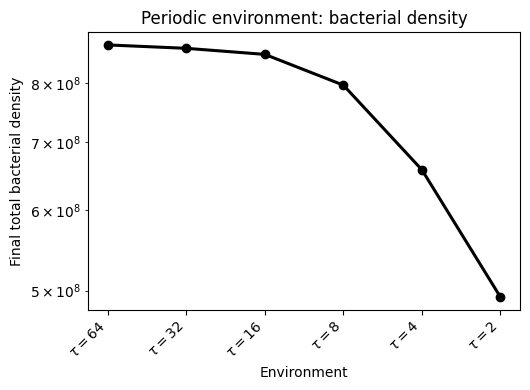

In [ ]:
# Environment vs final total bacterial density

plot_df = exp4_df.copy()

# Preserve the order defined in tau_values
tau_order = [format_tau_for_filename(tau) for tau in tau_values]

plot_df["tau_name"] = plot_df["tau"].apply(format_tau_for_filename)
plot_df["tau_label"] = plot_df["tau"].apply(format_tau_label)

plot_df["tau_name"] = pd.Categorical(
    plot_df["tau_name"],
    categories=tau_order,
    ordered=True,
)

plot_df = plot_df.sort_values("tau_name").reset_index(drop=True)

x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(5.4, 4.0))

ax.plot(
    x,
    plot_df["bacterial_density"],
    marker="o",
    linewidth=2.2,
    color="black",
)

ax.set_yscale("log")

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["tau_label"],
    rotation=45,
    ha="right",
)

ax.set_xlabel("Environment")
ax.set_ylabel("Final total bacterial density")
ax.set_title("Periodic environment: bacterial density")

fig.tight_layout()

save_file = exp4_fig_path / "environment_vs_total_density.png"
fig.savefig(save_file, dpi=300, bbox_inches="tight")

print("Saved figure to:", save_file)
